# Proceso Analítica de Datos usando Resultados Agregados ICFES 2018 - 2025

## Bases de datos de resultados agregados 2018-2025 descargados de la página del ICFES:
https://www.icfes.gov.co/evaluaciones-icfes/acerca-del-examen-saber-pro/resultados-del-examen-saber-pro/ 

**Marco y Ficha Metodológica:**
Específico de análisis de datos usado por el ICFES.</br>
https://www.icfes.gov.co/analisis-de-datos/

**SNIES:**
(para comparación)</br>
https://hecaa.mineducacion.gov.co/consultaspublicas/programas

**DIVIPOLA:**
(para comparación) Descarga directa.</br>
https://geoportal.dane.gov.co/descargas/divipola/Listados_DIVIPOLA.xlsx

In [1]:
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os
from pathlib import Path
import unicodedata
from difflib import get_close_matches # Para comparación de cadenas por similitud
import warnings # Control de advertencias
import time # Usado para temporizadores de ejecución
import sqlite3 # Uso básico de base de datos SQL

print('\nLibrerías instaladas e importadas!')

Note: you may need to restart the kernel to use updated packages.

Librerías instaladas e importadas!


## **Primera fase de proceso ETL de analítica:**
Recopilación (_Extracción_) de datos.

In [2]:
# Carga de archivos xlsx
# Ruta base
filepath = Path("C:/Users/NaujAlkml/Documents/IT-Stuff")
# filepath_source = Path("Ruta/de/origen") # En caso de dejar con acceso público - Adaptar donde corresponda.
# filepath_output = Path("Ruta/de/salida") # dejar estos como editables por el usuario - Adaptar donde corresponda.

# Años a cargar (un archivo excel por cada año)
years = list(range(2018, 2026))

# Función de carga de datos
def load_saber_pro_year(years, filepath):
    archivo = filepath / f"Base-de-datos-de-resultados-agregados-de-saber-pro-{year}.xlsx"
    if not archivo.exists():
        print(f"⚠️ Archivo no encontrado: {archivo}")
        return None
    
    df = pd.read_excel(archivo)
    # ---> Estandarizar nombre de columna histórica a NBC<---
    if 'NOMBRE_NBC' in df.columns:
        df.rename(columns={'NOMBRE_NBC': 'NBC'}, inplace=True)
    
    # Validación mínima: columnas esperadas
    columnas_esperadas = [
        'EXAMEN', 'AGREGACION', 'MEDIDA_AGREGACION', 'CANTIDADEVALUADOS', 'ID_PAIS', 'ID_REGION',
        'NOMBRE_REGION', 'ID_DEPARTAMENTO', 'NOMBRE_DEPARTAMENTO', 'ID_MUNICIPIO', 'NOMBRE_MUNICIPIO',
        'ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_SEDE', 'NOMBRE_SEDE', 'ID_GRUPOREFERENCIA',
        'NOMBRE_GRUPOREF', 'ID_NBC', 'NBC', 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD',
        'NOMBRE_PRUEBA', 'CATEGORIAPRUEBA', 'PROMEDIO_GLOBAL', 'PROMEDIO_PRUEBA', 'DESVIACION',
        'PROMEDIO_PERCENTIL', 'NIVEL1', 'NIVEL2', 'NIVEL3', 'NIVEL4', 'NIVEL5', 'AFIRMACION',
        'PORCENTAJERTAINCORRECTA'
    ]
    # Identificar columnas faltantes
    columnas_faltantes = [col for col in columnas_esperadas if col not in df.columns]
    
    if columnas_faltantes:
        print(f"⚠️ Estructura incompleta en el año {year}. Faltan: {columnas_faltantes}. Se añadirán vacías.")
        for col in columnas_faltantes:
            df[col] = pd.Series(dtype="object")            
    # Asegurar orden exacto de las columnas esperadas.
    df = df[columnas_esperadas]
    
    # Añadir columna de año para trazabilidad
    df['ANIO'] = year
    return df
print('Función cargada.')

Función cargada.


In [3]:
# Carga y consolidación de datos ICFES
print("*** Iniciada carga de registros a la base de datos maestra. ***")
start_time = time.time()

dataframes = []
for year in years:
    df_year = load_saber_pro_year(year, filepath)
    if df_year is not None:
        dataframes.append(df_year)
        print(f"✓ Cargado {year}: {len(df_year):,} registros")

if dataframes:
    sabpro_full = pd.concat(dataframes, ignore_index=True)
    print(f"Total consolidado: {len(sabpro_full):,} registros")
else:
    print("No se cargó ningún archivo.")

end_time = time.time()
elapsed = end_time - start_time
print(f"Tiempo de ejecución: {elapsed:.2f} segundos")

*** Iniciada carga de registros a la base de datos maestra. ***
⚠️ Estructura incompleta en el año 2018. Faltan: ['ID_REGION', 'ID_DEPARTAMENTO', 'ID_MUNICIPIO', 'ID_GRUPOREFERENCIA', 'ID_NBC', 'ID_PROGRAMA_ACAD', 'CATEGORIAPRUEBA']. Se añadirán vacías.
✓ Cargado 2018: 531,201 registros
⚠️ Estructura incompleta en el año 2019. Faltan: ['CATEGORIAPRUEBA']. Se añadirán vacías.
✓ Cargado 2019: 198,849 registros
✓ Cargado 2020: 245,234 registros
✓ Cargado 2021: 353,498 registros
✓ Cargado 2022: 406,672 registros
✓ Cargado 2023: 313,455 registros
✓ Cargado 2024: 411,946 registros
✓ Cargado 2025: 371,490 registros


C:\Users\NaujAlkml\AppData\Local\Temp\ipykernel_8532\3139909014.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sabpro_full = pd.concat(dataframes, ignore_index=True)


Total consolidado: 2,832,345 registros
Tiempo de ejecución: 829.99 segundos


In [4]:
#SNIES
print("*** Iniciada carga de registros a la base de datos SNIES. ***")
start_time = time.time()

# Ruta del archivo (ajustarla si es necesario)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    db_snies = pd.read_excel(filepath / f"SNIES_Programas.xlsx", sheet_name="Programas")
    # Ignorar filas irrelevantes como: pie de página, conservando registros válidos y pertientes
    db_snies = db_snies.dropna(subset=['NOMBRE_INSTITUCIÓN', 'TITULO_OTORGADO', 'NÚCLEO_BÁSICO_DEL_CONOCIMIENTO'], how='all')
print(f"Dataset SNIES cargado: {db_snies.shape}")

end_time = time.time()
elapsed = end_time - start_time
print(f"Tiempo de ejecución: {elapsed:.2f} segundos")

*** Iniciada carga de registros a la base de datos SNIES. ***
Dataset SNIES cargado: (31081, 39)
Tiempo de ejecución: 30.84 segundos


In [5]:
# =============================================================================
# BLOQUE OPCIONAL: COMPLEMENTO GEOGRÁFICO (DIVIPOLA - DANE)
# =============================================================================
# Descomentar este bloque si se desea añadir la dimensión geográfica a la normalización según 
# División Político-Administrativa oficial del país.

"""
path_divipola = filepath / "Listados_DIVIPOLA.xlsx"

if path_divipola.exists():
    print("\nCargando y depurando base de datos DIVIPOLA...")
    
    # Columnas de interés (Código/Nombre) para Departamento, Municipio, Centro poblado; Tipo, Logitud, Latitud, Nota
    columnas_validas = "A:J" 
    
    # Slicing de registros de interés - Headers fila 11 (xlsx); header=10. Registros hasta fila 8431 (8431-11=8420)
    db_divipola = pd.read_excel(
        path_divipola,
        sheet_name="Cabeceras - Centros Poblados",
        header=10,
        nrows=8420,
        usecols=columnas_validas,
        dtype=str             # Forzar strings para conservar el cero a la izquierda de los códigos.
    ) # Equivalente a la selección del rango A11:J8431 en Excel
    
    # Estandarización de Headers, evitando nombres duplicados de Excel
    db_divipola.columns = [
        'COD_DEPTO', 'NOM_DEPTO', 
        'COD_MUNICIPIO', 'NOM_MUNICIPIO', 
        'COD_CENTRO_POB', 'NOM_CENTRO_POB', 
        'TIPO', 'LONGITUD', 
        'LATITUD', 'NOTA'
    ]
    
    # Limpieza rápida de seguridad - Eliminación de espacios en blanco antes/después
    for col in db_divipola.columns:
        db_divipola[col] = db_divipola[col].str.strip()
        
    print(f"--> DIVIPOLA cargada exitosamente. Dimensiones: {db_divipola.shape}")
    print(db_divipola.sample(3))
else:
    print("\n[ADVERTENCIA] Archivo 'Listados_DIVIPOLA.xlsx' no encontrado. Se omite el cruce geográfico.")
"""

'\npath_divipola = filepath / "Listados_DIVIPOLA.xlsx"\n\nif path_divipola.exists():\n    print("\nCargando y depurando base de datos DIVIPOLA...")\n\n    # Columnas de interés (Código/Nombre) para Departamento, Municipio, Centro poblado; Tipo, Logitud, Latitud, Nota\n    columnas_validas = "A:J" \n\n    # Slicing de registros de interés - Headers fila 11 (xlsx); header=10. Registros hasta fila 8431 (8431-11=8420)\n    db_divipola = pd.read_excel(\n        path_divipola,\n        sheet_name="Cabeceras - Centros Poblados",\n        header=10,\n        nrows=8420,\n        usecols=columnas_validas,\n        dtype=str             # Forzar strings para conservar el cero a la izquierda de los códigos.\n    ) # Equivalente a la selección del rango A11:J8431 en Excel\n\n    # Estandarización de Headers, evitando nombres duplicados de Excel\n    db_divipola.columns = [\n        \'COD_DEPTO\', \'NOM_DEPTO\', \n        \'COD_MUNICIPIO\', \'NOM_MUNICIPIO\', \n        \'COD_CENTRO_POB\', \'NOM_CEN

### Considerar cargar todos los archivos comparadores desde el principio.
DIVIPOLA: _Listados_DIVIPOLA.xlsx_ (opcional. Podría incluirse en el diccionario global de normalización de nombres si se extiende a la dimensión geográfica)</br>
Exportarlos en formato _.parquet_ para aumentar eficiencia en la lectura de datos.

In [5]:
# Extracción de base de datos completa a '.parquet'
sabpro_full.to_parquet('saberpro_2018_2025.parquet')
db_snies.to_parquet('SNIES_database.parquet')
# db_divipola.to_parquet('DIVIPOLA_database.parquet') # Descomentar si se usa
print('Exitosamente eportados en formato .parquet.')

Exitosamente eportados en formato .parquet.


## **Segunda fase de proceso ETL de analítica:**

### Análisis exploratorio de datos (EDA)

In [6]:
sabpro_full.sample(4)

,EXAMEN,AGREGACION,MEDIDA_AGREGACION,CANTIDADEVALUADOS,ID_PAIS,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,...,DESVIACION,PROMEDIO_PERCENTIL,NIVEL1,NIVEL2,NIVEL3,NIVEL4,NIVEL5,AFIRMACION,PORCENTAJERTAINCORRECTA,ANIO
2766264,SABER PRO - 2025,PROGRAMA_ACÁDEMICO,NIVEL_DESEMPEÑO_PRUEBA,28,1,2.0,ANDINA,22.0,SANTANDER,850.0,...,NaN,NaN,39.0,43.0,18.0,0.0,NaN,NaN,NaN,2025
765906,SABER PRO - 2020,NBC_INSTITUCION,APRENDIZAJE_PRUEBA,437,1,6.0,PACÍFICA,25.0,VALLE,1010.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Identifica y entiende los contenidos locales q...,33.0,2020
956239,SABER PRO - 2020,PROGRAMA_ACÁDEMICO,PUNTAJE_PRUEBA,9,1,2.0,ANDINA,4.0,BOGOTÁ,152.0,...,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
980051,SABER PRO - 2021,INSTITUCIÓN,APRENDIZAJE_PRUEBA,9438,1,2.0,ANDINA,4.0,BOGOTÁ,152.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comprende que los problemas y sus soluciones i...,45.0,2021


In [7]:
db_snies.sample(5)

,CÓDIGO_INSTITUCIÓN_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO_INSTITUCIÓN,CARÁCTER_ACADÉMICO,SECTOR,REGISTRO_UNICO,CÓDIGO_SNIES_DEL_PROGRAMA,CÓDIGO_ANTERIOR_ICFES,NOMBRE_DEL_PROGRAMA,...,NÚMERO_PERIODOS_DE_DURACIÓN,PERIODICIDAD,SE_OFRECE_POR_CICLOS_PROPEDÉUT,PERIODICIDAD_ADMISIONES,PROGRAMA_EN_CONVENIO,DEPARTAMENTO_OFERTA_PROGRAMA,MUNICIPIO_OFERTA_PROGRAMA,COSTO_MATRÍCULA_ESTUD_NUEVOS,VIGENCIA TRANSITORIA,OBSERVACIÓN DECRETO 1174/23
4913,1207,1207,UNIVERSIDAD DEL TOLIMA,Activa,Universidad,Oficial,NaN,54934.0,54934,ADMINISTRACION DE EMPRESAS TURISTICAS,...,10.0,Semestral,No,Sin definir,N,Tolima,Ibagué,NaN,NaN,NaN
23445,2849,2849,CORPORACION UNIVERSITARIA AUTONOMA DEL CAUCA,Activa,Institución Universitaria/Escuela Tecnológica,Privado,NaN,110670.0,110670,MATEMÁTICAS APLICADAS EN CIENCIA DE DATOS,...,8.0,Semestral,No,Semestral,N,Cauca,Popayán,NaN,NaN,NaN
19724,2728,2728,FUNDACION UNIVERSITARIA DEL AREA ANDINA,Activa,Institución Universitaria/Escuela Tecnológica,Privado,NaN,110876.0,110876,ENFERMERÍA,...,9.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",8250000.0,NaN,NaN
8993,1711,1711,UNIVERSIDAD DE LA SABANA,Activa,Universidad,Privado,NaN,90806.0,90806,FILOSOFÍA,...,8.0,Semestral,No,Semestral,N,Cundinamarca,Chía,10309103.0,NaN,NaN
23574,2905,2905,CENTRO DE EDUCACION MILITAR - CEMIL,Activa,Institución Universitaria/Escuela Tecnológica,Oficial,NaN,11100.0,290553330701100113400,ESPECIALIZACION EN GESTION AMBIENTAL Y DESARRO...,...,2.0,Semestral,No,Anual,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN


In [8]:
# ==============================================================================
# Perfilamiento segmentado (Numéricos vs Texto)
# ==============================================================================

def resumen_numerico_simple(col):
    datos = col.dropna()
    return {
        'Columna': col.name,
        'Tipo_dato': str(col.dtype),
        'Nulos_%': round(col.isnull().sum() / len(col) * 100, 2),
        'Únicos': col.nunique(),
        'Mínimo': datos.min(),
        'Máximo': datos.max(),
        'Media': round(datos.mean(), 2),
        'Mediana': round(datos.median(), 2),
        'Desv_estándar': round(datos.std(), 2)
    }

def resumen_texto_simple(col):
    datos = col.dropna().astype(str)
    # Muestra hasta 3 ejemplos distintos (sin nulos)
    ejemplos = datos.unique()[:3].tolist()
    # Truncar cada ejemplo a 80 caracteres para no saturar
    ejemplos_trunc = [e[:80] + '…' if len(e) > 80 else e for e in ejemplos]
    return {
        'Columna': col.name,
        'Tipo_dato': str(col.dtype),
        'Nulos_%': round(col.isnull().sum() / len(col) * 100, 2),
        'Únicos': col.nunique(),
        # 'Longitud_media_(caracteres)': round(datos.str.len().mean(), 1),
        'Palabras_media': round(datos.str.split().str.len().mean(), 1),
        'Ejemplos': ejemplos_trunc
    }

# Separar columnas según tipo real
cols_numericas = sabpro_full.select_dtypes(include=['int64', 'float64']).columns
cols_texto = sabpro_full.select_dtypes(include=['object']).columns

# Construir dataframes de resumen
df_glosario_num = pd.DataFrame([resumen_numerico_simple(sabpro_full[c]) for c in cols_numericas])
df_glosario_txt = pd.DataFrame([resumen_texto_simple(sabpro_full[c]) for c in cols_texto])

# Mostrar con estilo profesional
print("📊 **GLOSARIO DE VARIABLES NUMÉRICAS**")
display(df_glosario_num.style.background_gradient(cmap='Reds', subset=['Nulos_%']).set_caption("Variables Numéricas - Saber Pro (2018-2025)"))

print("\n📝 **GLOSARIO DE VARIABLES DE TEXTO**")
display(df_glosario_txt.style.background_gradient(cmap='Blues', subset=['Nulos_%']).set_caption("Variables de Texto - Saber Pro (2018-2025)"))

# Opcional: exportar ambos glosarios a Excel/CSV para documentación
with pd.ExcelWriter('glosario_saberpro_2018_2025.xlsx') as writer:
    df_glosario_num.to_excel(writer, sheet_name='Numericas', index=False)
    df_glosario_txt.to_excel(writer, sheet_name='Texto', index=False)
print("\nGlosario exportado a 'glosario_saberpro_2018_2025.xlsx'")

📊 **GLOSARIO DE VARIABLES NUMÉRICAS**


,Columna,Tipo_dato,Nulos_%,Únicos,Mínimo,Máximo,Media,Mediana,Desv_estándar
0,CANTIDADEVALUADOS,int64,0.000000,18905,1.000000,3360108.000000,730.500000,100.000000,12397.040000
1,ID_PAIS,int64,0.000000,1,1.000000,1.000000,1.000000,1.000000,0.000000
2,ID_REGION,float64,19.400000,5,1.000000,6.000000,2.700000,2.000000,1.360000
3,ID_DEPARTAMENTO,float64,19.510000,26,1.000000,28.000000,9.460000,4.000000,8.480000
4,ID_MUNICIPIO,float64,20.070000,63,1.000000,1078.000000,375.210000,152.000000,347.510000
5,ID_INSTITUCION,float64,2.400000,238,5264.000000,33840.000000,9160.840000,9049.000000,1429.590000
6,ID_SEDE,float64,31.430000,283,5264.000000,33843.000000,9164.440000,9064.000000,1412.880000
7,ID_GRUPOREFERENCIA,float64,69.920000,29,1.000000,83.000000,14.820000,10.000000,16.260000
8,ID_NBC,float64,43.020000,56,1.000000,99.000000,29.490000,27.000000,19.850000
9,ID_PROGRAMA_ACAD,float64,69.800000,5323,4.000000,32317.000000,5919.940000,4826.000000,5611.550000



📝 **GLOSARIO DE VARIABLES DE TEXTO**


,Columna,Tipo_dato,Nulos_%,Únicos,Palabras_media,Ejemplos
0,EXAMEN,object,0.000000,8,4.000000,"['SABER PRO - 2018', 'SABER PRO - 2019', 'SABER PRO - 2020']"
1,AGREGACION,object,0.000000,14,1.000000,"['GRUPOREFERENCIA_SEDE', 'GRUPOREFERENCIA_INSTITUCION', 'PROGRAMA_ACÁDEMICO']"
2,MEDIDA_AGREGACION,object,0.000000,6,1.000000,"['PUNTAJE_PRUEBA', 'PERCENTIL_PRUEBA', 'PERCENTIL_GLOBAL']"
3,NOMBRE_REGION,object,0.690000,5,1.000000,"['ANDINA', 'CARIBE', 'PACÍFICA']"
4,NOMBRE_DEPARTAMENTO,object,0.820000,27,1.000000,"['BOGOTA', 'ANTIOQUIA', 'CALDAS']"
5,NOMBRE_MUNICIPIO,object,1.470000,64,1.400000,"['BOGOTÁ D.C.', 'MEDELLÍN', 'MANIZALES']"
6,NOMBRE_INSTITUCION,object,2.400000,243,4.100000,"['PONTIFICIA UNIVERSIDAD JAVERIANA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'FUNDACION UNIVERSITARIA LUIS AMIGO FUNLAM']"
7,NOMBRE_SEDE,object,31.430000,291,4.500000,"['PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.', 'UNIVERSIDAD NACIONAL DE COLOMBIA-BOGOTÁ D.C.', 'FUNDACION UNIVERSITARIA LUIS AMIGO FUNLAM-MEDELLIN']"
8,NOMBRE_GRUPOREF,object,59.700000,29,2.000000,"['INGENIERÍA', 'HUMANIDADES', 'CIENCIAS SOCIALES']"
9,NBC,object,35.470000,56,2.900000,"['COMUNICACIÓN SOCIAL, PERIODISMO Y AFINES', 'ADMINISTRACIÓN', 'ODONTOLOGÍA']"



Glosario exportado a 'glosario_saberpro_2018_2025.xlsx'



=== VISUALIZACIONES EXPLORATORIAS ===


C:\Users\NaujAlkml\AppData\Local\Temp\ipykernel_8532\2534060152.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sabpro_full, x='ANIO', palette='Blues_d')


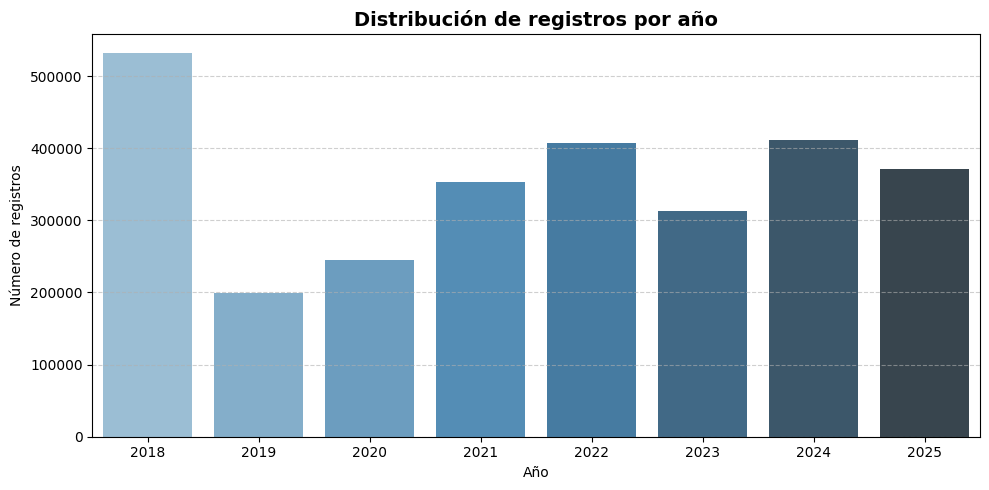

C:\Users\NaujAlkml\AppData\Local\Temp\ipykernel_8532\2534060152.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agregacion_counts.values, y=agregacion_counts.index, palette='viridis')


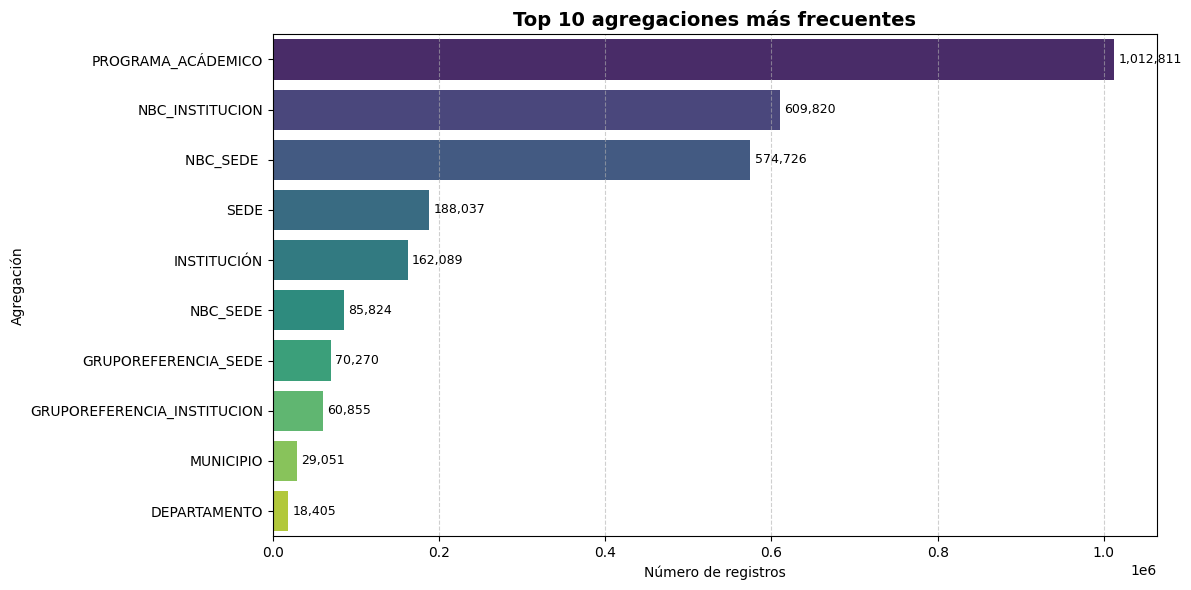

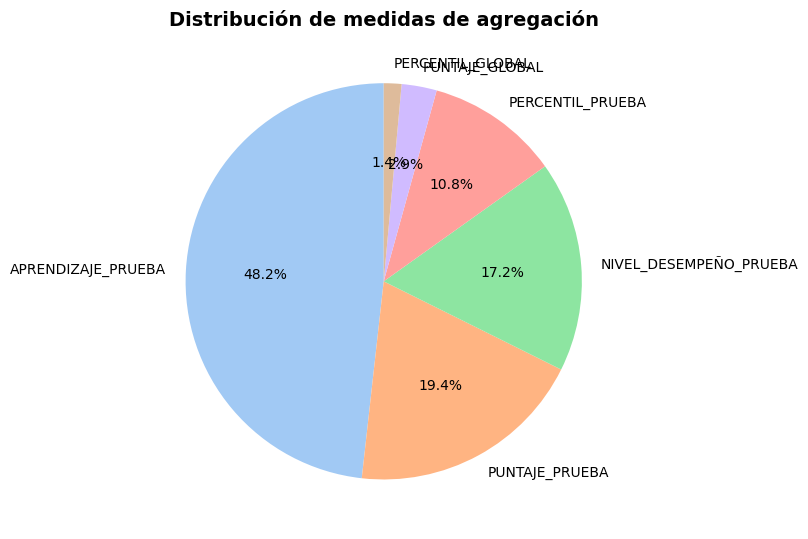

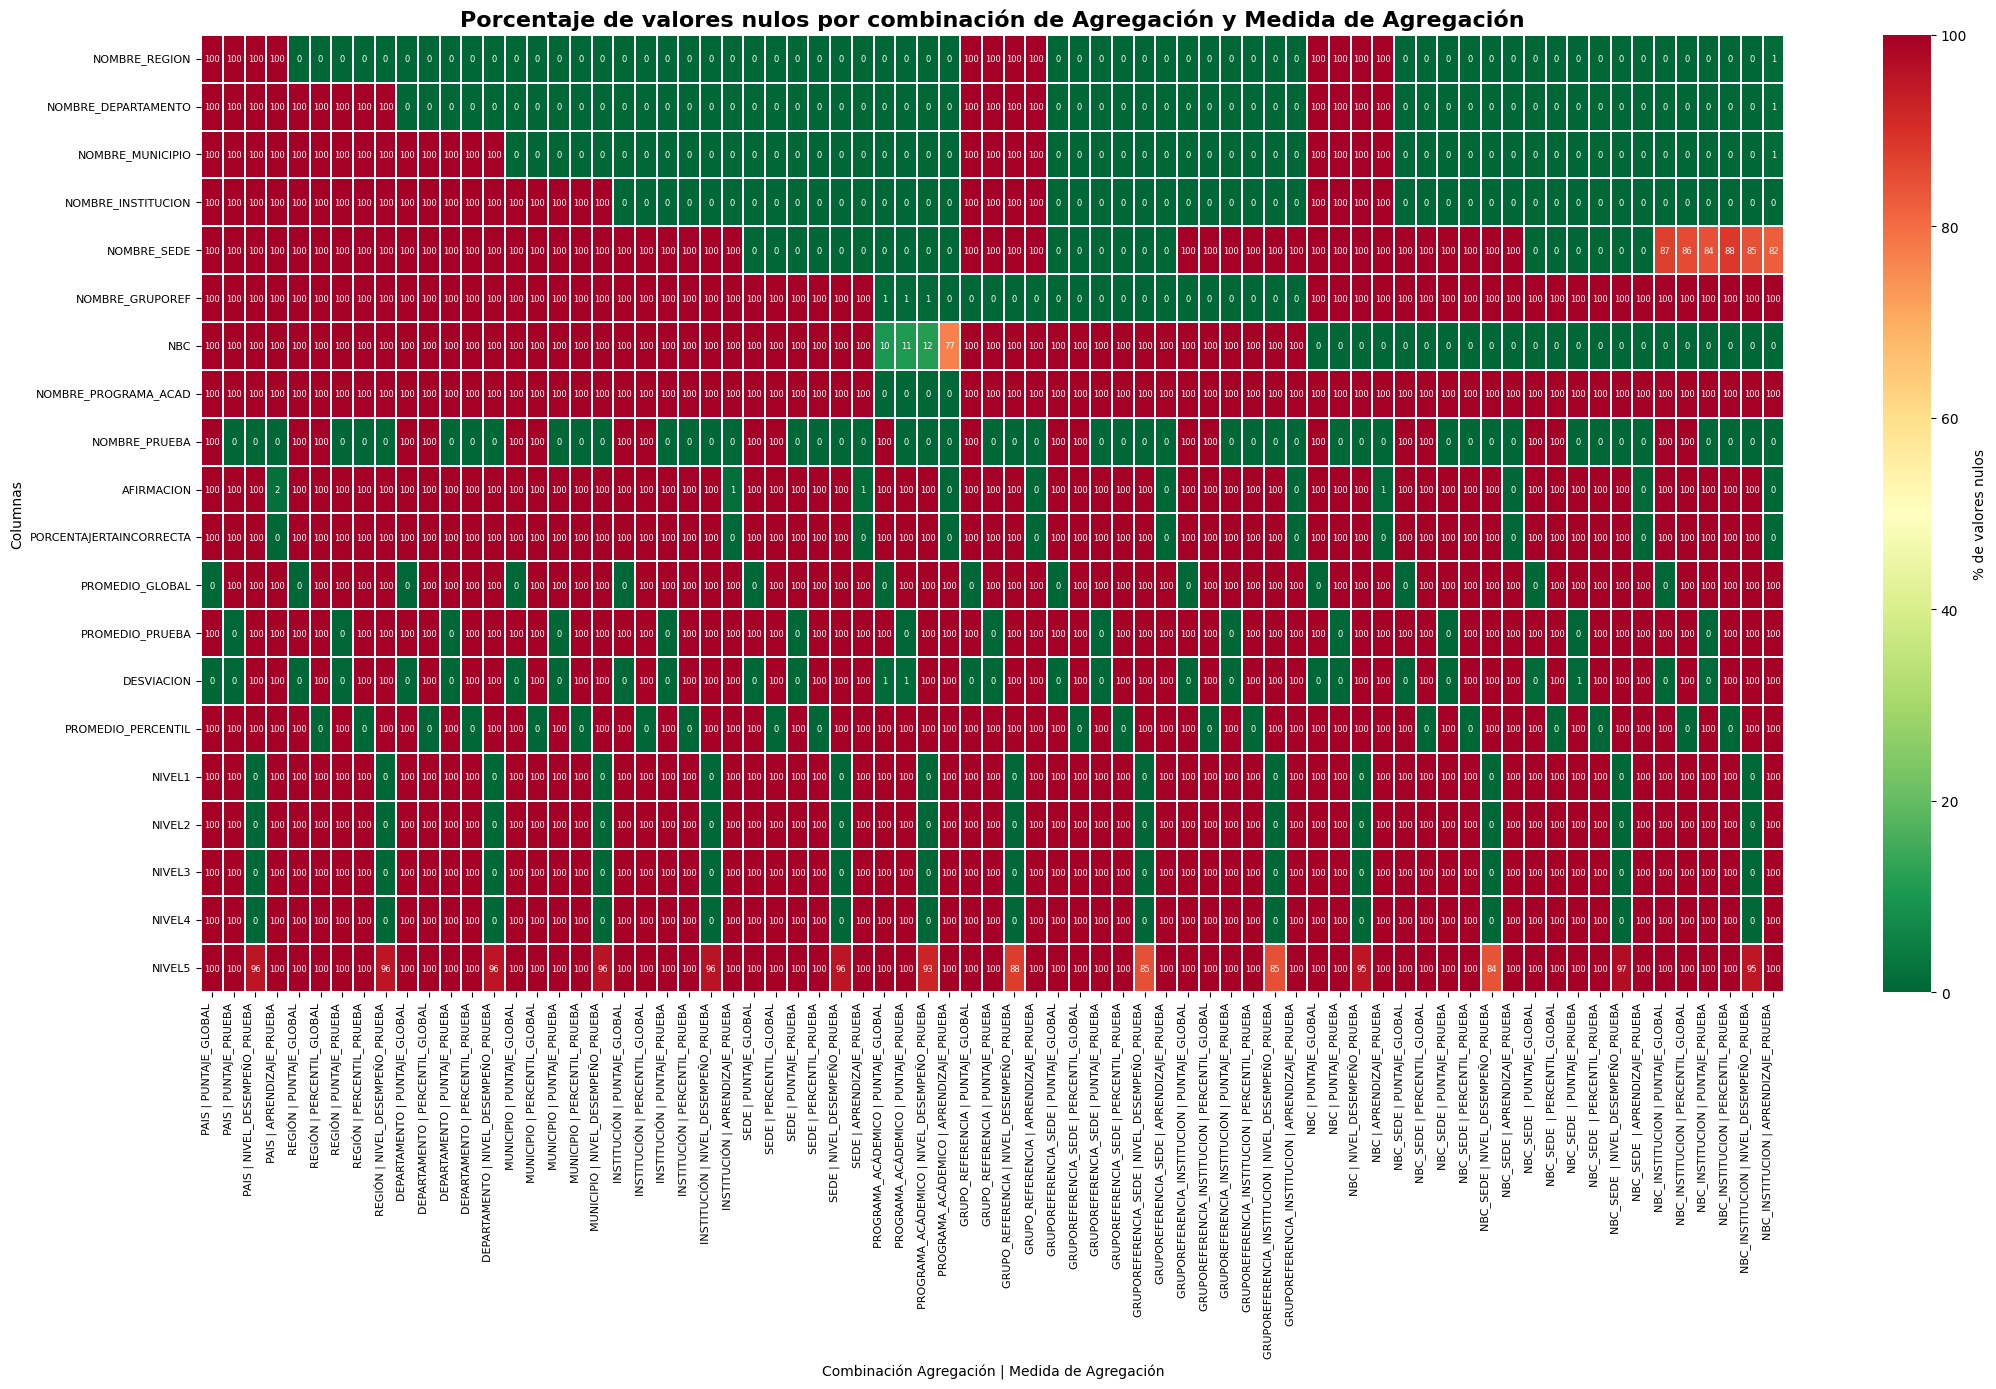

✅ Visualizaciones exploratorias guardadas.


In [13]:
# =============================================================================
# VISUALIZACIONES EXPLORATORIAS (EDA Gráfico)
# =============================================================================
print("\n=== VISUALIZACIONES EXPLORATORIAS ===")

# 1. Distribución de registros por año
plt.figure(figsize=(10,5))
sns.countplot(data=sabpro_full, x='ANIO', palette='Blues_d')
plt.title('Distribución de registros por año', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de registros')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribucion_por_anio.png', dpi=300)
plt.show()

# 2. Frecuencia de agregaciones (top 10)
plt.figure(figsize=(12,6))
agregacion_counts = sabpro_full['AGREGACION'].value_counts().head(10)
sns.barplot(x=agregacion_counts.values, y=agregacion_counts.index, palette='viridis')
plt.title('Top 10 agregaciones más frecuentes', fontsize=14, fontweight='bold')
plt.xlabel('Número de registros')
plt.ylabel('Agregación')
plt.grid(axis='x', linestyle='--', alpha=0.6)
# Añadir etiquetas de valor
for i, v in enumerate(agregacion_counts.values):
    plt.text(v + 5000, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('frecuencia_agregaciones.png', dpi=300)
plt.show()

# 3. Distribución de medidas de agregación
plt.figure(figsize=(8,8))
medida_counts = sabpro_full['MEDIDA_AGREGACION'].value_counts()
plt.pie(medida_counts.values, labels=medida_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Distribución de medidas de agregación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_medidas.png', dpi=300)
plt.show()

# 4. Heatmap de nulos (representación de granularidad de datos)

# Columna combinada
sabpro_full['AGREGACION_MEDIDA'] = sabpro_full['AGREGACION'] + ' | ' + sabpro_full['MEDIDA_AGREGACION']

# Calcular porcentaje de nulos para cada combinación y columna
heatmap_data = sabpro_full.groupby('AGREGACION_MEDIDA')[columnas_interes].apply(
    lambda x: x.isna().mean() * 100
).reset_index()

# Pivotar
heatmap_pivot = heatmap_data.set_index('AGREGACION_MEDIDA').T

# Ordenar columnas: primero por AGREGACION, luego por MEDIDA
orden_agregacion = ['PAIS', 'REGIÓN', 'DEPARTAMENTO', 'MUNICIPIO', 
                    'INSTITUCIÓN', 'SEDE', 'PROGRAMA_ACÁDEMICO', 
                    'GRUPO_REFERENCIA', 'GRUPOREFERENCIA_SEDE', 'GRUPOREFERENCIA_INSTITUCION',
                    'NBC', 'NBC_SEDE', 'NBC_SEDE ', 'NBC_INSTITUCION']

orden_medida = ['PUNTAJE_GLOBAL', 'PERCENTIL_GLOBAL', 'PUNTAJE_PRUEBA', 
                'PERCENTIL_PRUEBA', 'NIVEL_DESEMPEÑO_PRUEBA', 'APRENDIZAJE_PRUEBA']

# Orden de columnas combinado
columnas_ordenadas = []
for agg in orden_agregacion:
    for med in orden_medida:
        col_name = f"{agg} | {med}"
        if col_name in heatmap_pivot.columns:
            columnas_ordenadas.append(col_name)

# Reordenar el heatmap
heatmap_pivot_ordenado = heatmap_pivot[columnas_ordenadas]

# Generar heatmap con etiquetas
plt.figure(figsize=(22, 14))
sns.heatmap(heatmap_pivot_ordenado, 
            cmap='RdYlGn_r',
            annot=True,
            fmt='.0f',
            cbar_kws={'label': '% de valores nulos'},
            linewidths=0.3,
            linecolor='white',
            square=False,
            annot_kws={'fontsize': 6})
plt.title('Porcentaje de valores nulos por combinación de Agregación y Medida de Agregación', 
          fontsize=16, fontweight='bold')
plt.xlabel('Combinación Agregación | Medida de Agregación')
plt.ylabel('Columnas')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('heatmap_nulos_ordenado.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizaciones exploratorias guardadas.")

### Exploración de hallazgo en _Heatmap_
**Análisis de _'NBC_SEDE'_ Vs. _'NBC_SEDE '_:** Además de la diferencia en los nombres de columna se detecta una diferencia de valores nulos en 'NOMBRE_SEDE' de 100% y 0% respectivamente.

In [14]:
# =============================================================================
# EXPLORACIÓN DE POSIBLE DUPLICIDAD: NBC_SEDE
# =============================================================================
print("=== EXPLORACIÓN DE 'NBC_SEDE' vs 'NBC_SEDE ' ===")

# 1. Contar registros por cada Agregación
print("Registros con 'NBC_SEDE ':", len(sabpro_full[sabpro_full['AGREGACION'] == 'NBC_SEDE ']))
print("Registros con 'NBC_SEDE':", len(sabpro_full[sabpro_full['AGREGACION'] == 'NBC_SEDE']))

# 2. Ver distribución de MEDIDA_AGREGACION
print("\nMedidas asociadas a 'NBC_SEDE ':")
print(sabpro_full[sabpro_full['AGREGACION'] == 'NBC_SEDE ']['MEDIDA_AGREGACION'].value_counts())

print("\nMedidas asociadas a 'NBC_SEDE':")
print(sabpro_full[sabpro_full['AGREGACION'] == 'NBC_SEDE']['MEDIDA_AGREGACION'].value_counts())

# 3. Verificar si hay filas con mismo ID_NBC y NOMBRE_SEDE
# (cruzar con columnas relevantes para ver si la información es redundante)
print("\nEjemplo de valores en ambas agregaciones:")
sample1 = sabpro_full[sabpro_full['AGREGACION'] == 'NBC_SEDE '][['ID_NBC', 'NBC', 'NOMBRE_SEDE', 'MEDIDA_AGREGACION']].head(3)
sample2 = sabpro_full[sabpro_full['AGREGACION'] == 'NBC_SEDE'][['ID_NBC', 'NBC', 'NOMBRE_SEDE', 'MEDIDA_AGREGACION']].head(3)
print("NBC_SEDE :")
print(sample1)
print("\nNBC_SEDE:")
print(sample2)


=== EXPLORACIÓN DE 'NBC_SEDE' vs 'NBC_SEDE ' ===
Registros con 'NBC_SEDE ': 574726
Registros con 'NBC_SEDE': 85824

Medidas asociadas a 'NBC_SEDE ':
MEDIDA_AGREGACION
APRENDIZAJE_PRUEBA        253615
PUNTAJE_PRUEBA             97633
PERCENTIL_PRUEBA           97633
NIVEL_DESEMPEÑO_PRUEBA     92837
PUNTAJE_GLOBAL             17677
PERCENTIL_GLOBAL           15331
Name: count, dtype: int64

Medidas asociadas a 'NBC_SEDE':
MEDIDA_AGREGACION
APRENDIZAJE_PRUEBA        43797
PUNTAJE_PRUEBA            14292
NIVEL_DESEMPEÑO_PRUEBA    13310
PERCENTIL_PRUEBA          10303
PERCENTIL_GLOBAL           2061
PUNTAJE_GLOBAL             2061
Name: count, dtype: int64

Ejemplo de valores en ambas agregaciones:
NBC_SEDE :
        ID_NBC                                                NBC  \
536654    29.0  INGENIERÍA ELECTRÓNICA, TELECOMUNICACIONES Y A...   
536655    69.0                SOCIOLOGÍA, TRABAJO SOCIAL Y AFINES   
536659    20.0           INGENIERÍA AMBIENTAL, SANITARIA Y AFINES   

        

In [15]:
# =============================================================================
# DIAGNÓSTICO DE 'NBC_SEDE' vs 'NBC_SEDE '
# =============================================================================
print("\n=== DIAGNÓSTICO DE DIFERENCIAS ENTRE NBC_SEDE Y NBC_SEDE ===")

# Filtrar solo las dos agregaciones
mask_nbc_sede = sabpro_full['AGREGACION'].isin(['NBC_SEDE', 'NBC_SEDE '])
df_nbc = sabpro_full[mask_nbc_sede].copy()

# 1. Distribución de años por agregación
print("\n--- Distribución de años por agregación ---")
anios_por_agregacion = df_nbc.groupby(['AGREGACION', 'ANIO']).size().unstack(fill_value=0)
print(anios_por_agregacion)

# 2. Porcentaje de nulos en NOMBRE_SEDE por agregación y año
print("\n--- Porcentaje de nulos en NOMBRE_SEDE por agregación y año ---")
nulos_sede = df_nbc.groupby(['AGREGACION', 'ANIO'])['NOMBRE_SEDE'].apply(lambda x: x.isna().mean() * 100).unstack(fill_value=0)
print(nulos_sede.round(2))

# 3. Porcentaje de nulos en otras columnas clave
print("\n--- Porcentaje de nulos en columnas clave por agregación (global) ---")
columnas_clave = ['ID_SEDE', 'NOMBRE_INSTITUCION', 'ID_NBC', 'NBC', 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD']
for col in columnas_clave:
    nulos_global = df_nbc.groupby('AGREGACION')[col].apply(lambda x: x.isna().mean() * 100)
    print(f"{col}:")
    print(nulos_global.round(2))

# 4. Mostrar ejemplos de filas de cada agregación (con columnas relevantes)
print("\n--- Ejemplos de filas de 'NBC_SEDE ' (con espacio) ---")
display(df_nbc[df_nbc['AGREGACION'] == 'NBC_SEDE '][['ANIO', 'NOMBRE_SEDE', 'ID_SEDE', 'NOMBRE_INSTITUCION', 'ID_NBC', 'NBC']].sample(5))

print("\n--- Ejemplos de filas de 'NBC_SEDE' (sin espacio) ---")
display(df_nbc[df_nbc['AGREGACION'] == 'NBC_SEDE'][['ANIO', 'NOMBRE_SEDE', 'ID_SEDE', 'NOMBRE_INSTITUCION', 'ID_NBC', 'NBC']].sample(5))


=== DIAGNÓSTICO DE DIFERENCIAS ENTRE NBC_SEDE Y NBC_SEDE ===

--- Distribución de años por agregación ---
ANIO         2018  2019   2020   2021    2022   2023    2024    2025
AGREGACION                                                          
NBC_SEDE    85824     0      0      0       0      0       0       0
NBC_SEDE        0  2346  71969  95229  107917  87064  109335  100866

--- Porcentaje de nulos en NOMBRE_SEDE por agregación y año ---
ANIO         2018  2019  2020  2021  2022  2023  2024  2025
AGREGACION                                                 
NBC_SEDE    100.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
NBC_SEDE      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0

--- Porcentaje de nulos en columnas clave por agregación (global) ---
ID_SEDE:
AGREGACION
NBC_SEDE     100.0
NBC_SEDE       0.0
Name: ID_SEDE, dtype: float64
NOMBRE_INSTITUCION:
AGREGACION
NBC_SEDE     0.0
NBC_SEDE     0.0
Name: NOMBRE_INSTITUCION, dtype: float64
ID_NBC:
AGREGACION
NBC_SEDE     100.0
NBC_SEDE 

,ANIO,NOMBRE_SEDE,ID_SEDE,NOMBRE_INSTITUCION,ID_NBC,NBC
829486,2020,UNIVERSIDAD DEL MAGDALENA - UNIMAGDALENA-SANTA...,9139.0,UNIVERSIDAD DEL MAGDALENA,66.0,PSICOLOGÍA
2289199,2024,UNIVERSIDAD DE NARIÑO-PASTO,9146.0,UNIVERSIDAD DE NARIÑO,62.0,"GEOGRAFÍA, HISTORIA"
2640731,2025,UNIVERSIDAD ANTONIO NARIÑO-BOGOTÁ D.C.,9063.0,UNIVERSIDAD ANTONIO NARIÑO,27.0,"INGENIERÍA DE SISTEMAS, TELEMÁTICA Y AFINES"
2247115,2024,CORPORACION UNIVERSITARIA DEL CARIBE - CECAR-S...,9189.0,CORPORACION UNIVERSITARIA DEL CARIBE,58.0,"DEPORTES, EDUCACIÓN FÍSICA Y RECREACIÓN"
2243021,2024,CORPORACION UNIVERSITARIA DE SANTA ROSA DE CAB...,9167.0,CORPORACION UNIVERSITARIA DE SANTA ROSA DE CAB...,34.0,"BIOLOGÍA, MICROBIOLOGÍA Y AFINES"



--- Ejemplos de filas de 'NBC_SEDE' (sin espacio) ---


,ANIO,NOMBRE_SEDE,ID_SEDE,NOMBRE_INSTITUCION,ID_NBC,NBC
145195,2018,NaN,NaN,CORPORACION UNIVERSITARIA DE CIENCIA Y DESARROLLO,NaN,INGENIERÍA BIOMÉDICA Y AFINES
461034,2018,NaN,NaN,FUNDACION UNIVERSITARIA SAN MARTIN,NaN,MEDICINA
180280,2018,NaN,NaN,FUNDACION UNIVERSITARIA DE SAN GIL - UNISANGIL -,NaN,INGENIERÍA MECÁNICA Y AFINES
72150,2018,NaN,NaN,UNIVERSIDAD PEDAGOGICA NACIONAL,NaN,EDUCACIÓN
294246,2018,NaN,NaN,UNIVERSIDAD EL BOSQUE,NaN,"OPTOMETRÍA, OTROS PROGRAMAS DE CIENCIAS DE LA ..."


**Conclusión:** La diferencia se encuentra en un cambio del valor de agregación en 2018, que agrupa el 100% de valores nulos para la columna 'NOMBRE_SEDE' con respecto a los años posteriores. 

In [10]:
print("=== ESTRUCTURA SNIES ===")
print(f"Dimensiones: {db_snies.shape}")
print("\nColumnas:")
print(db_snies.columns.tolist())

=== ESTRUCTURA SNIES ===
Dimensiones: (31081, 39)

Columnas:
['CÓDIGO_INSTITUCIÓN_PADRE', 'CÓDIGO_INSTITUCIÓN', 'NOMBRE_INSTITUCIÓN', 'ESTADO_INSTITUCIÓN', 'CARÁCTER_ACADÉMICO', 'SECTOR', 'REGISTRO_UNICO', 'CÓDIGO_SNIES_DEL_PROGRAMA', 'CÓDIGO_ANTERIOR_ICFES', 'NOMBRE_DEL_PROGRAMA', 'TITULO_OTORGADO', 'ESTADO_PROGRAMA', 'JUSTIFICACION', 'JUSTIFICACION_DETALLADA', 'RECONOCIMIENTO_DEL_MINISTERIO', 'RESOLUCIÓN_DE_APROBACIÓN', 'FECHA_DE_RESOLUCIÓN', 'FECHA_EJECUTORIA', 'VIGENCIA_AÑOS', 'FECHA_DE_REGISTRO_EN_SNIES', 'CINE_F_2013_AC_CAMPO_AMPLIO', 'CINE_F_2013_AC_CAMPO_ESPECÍFIC', 'CINE_F_2013_AC_CAMPO_DETALLADO', 'ÁREA_DE_CONOCIMIENTO', 'NÚCLEO_BÁSICO_DEL_CONOCIMIENTO', 'NIVEL_ACADÉMICO', 'NIVEL_DE_FORMACIÓN', 'MODALIDAD', 'NÚMERO_CRÉDITOS', 'NÚMERO_PERIODOS_DE_DURACIÓN', 'PERIODICIDAD', 'SE_OFRECE_POR_CICLOS_PROPEDÉUT', 'PERIODICIDAD_ADMISIONES', 'PROGRAMA_EN_CONVENIO', 'DEPARTAMENTO_OFERTA_PROGRAMA', 'MUNICIPIO_OFERTA_PROGRAMA', 'COSTO_MATRÍCULA_ESTUD_NUEVOS', 'VIGENCIA TRANSITORIA', 'OBSE

### Transformación de datos:
**Normalización de texto de nombres en  columnas relevantes.**</br>
Se usan los archivos _.parquet_ y se ejecuta sobre Instituciones, Sedes, Programas académicos y NBC

**Pipeline de creación de diccionario:**

In [11]:
# 1. CARGA DE DATOS
# ==============================================================================
print("Cargando bases de datos...")
columnas_interes = ['NOMBRE_INSTITUCION', 'NOMBRE_SEDE', 'NOMBRE_PROGRAMA_ACAD', 'NBC']
df_icfes_raw = pd.read_parquet(r'C:\Users\NaujAlkml\Documents\IT-Stuff\Python_Jupyt-Colab_Prjcts\saberpro_2018_2025.parquet', 
                               columns=columnas_interes)

colnom_snies = ['NOMBRE_INSTITUCIÓN', 'NOMBRE_DEL_PROGRAMA', 'NÚCLEO_BÁSICO_DEL_CONOCIMIENTO']
db_snies = pd.read_parquet(r"C:\Users\NaujAlkml\Documents\IT-Stuff\Python_Jupyt-Colab_Prjcts\SNIES_database.parquet", columns=colnom_snies)

stopwords_mayus = {
    'A', 'AL', 'ANTE', 'AQUEL', 'AQUELLA', 'AQUELLAS', 'AQUELLOS', 'BAJO', 'COMO', 'CON', 'CONTRA', 'CUAL', 'CUALES', 'CUANDO', 
    'CUALQUIERA', 'CUYA', 'CUYAS', 'CUYO', 'CUYOS', 'CUÁL', 'CUÁLES', 'CUÁNDO', 'CÓMO', 'DE', 'DEL', 'DESDE', 'DONDE', 'DURANTE', 'DÓNDE', 
    'E', 'EL', 'EN', 'ENTRE', 'ESA', 'ESAS', 'ESE', 'ESOS', 'ESTA', 'ESTAS', 'ESTE', 'ESTOS', 'HACIA', 'HASTA', 'LA', 'LAS', 
    'LE', 'LES', 'LO', 'LOS', 'ME', 'MENOS', 'MUY', 'MÁS', 'NOS', 'O', 'OS', 'PARA', 'POR', 'QUE', 'QUIEN', 'QUIÉN', 'QUIÉNES', 
    'QUÉ', 'SE', 'SIN', 'SOBRE', 'TAN', 'TRAS', 'U', 'UN', 'UNA', 'UNAS', 'UNO', 'UNOS', 'Y', 'I', 'II', 'III', 'IV', 'V', 'VI', 'VII',
    'VIII', 'IX', 'X', 'XI', 'XII', 'XIII'
}

# 2. CLASE - Enfoque: Diccionario Único de Palabras
# ==============================================================================
class GeneradorDiccionarioUnificado:
    def __init__(self, df_icfes, df_snies, col_icfes, col_snies=None, stopwords=None):
        self.df_icfes = df_icfes
        self.df_snies = df_snies
        self.col_icfes = col_icfes
        self.col_snies = col_snies
        self.stopwords = stopwords or set()
        
        self.vocabulario_crudo = set()
        self.diccionario_final = []

    @staticmethod
    def _desacentuar(texto):
        return ''.join(c for c in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(c))

    def _extraer_palabras_crudas(self, series):
        """Extrae palabras INCLUYENDO símbolos (¿) y números (0) para no cortar raíces"""
        # Acepta letras (con/sin tilde), ¿, ¡ y números
        patron = r'[A-Za-zÁÉÍÓÚÑÜáéíóúñü¿¡0-9,.:\-_]+'
        palabras = set()
        for texto in series.dropna().astype(str):
            palabras.update(re.findall(patron, texto.upper()))
        return palabras

    def _generar_search_key(self, palabra):
        """Llave invisible para comparar: quita ¿, ¡, números y tildes"""
        limpia = re.sub(r'[¿¡0-9]', '', palabra)
        return self._desacentuar(limpia)

    def _detectar_tipo_error(self, palabra):
        """Etiqueta el error para facilitar el filtrado en Excel del usuario"""
        if re.search(r'[¿¡]', palabra): return "CODIFICACION (¿/¡)"
        if re.search(r'[0-9]', palabra): return "NUMERO POR LETRA"
        # Opcional: agregar detección de dobles/triples para flaggearlos sin corregirlos (descomentar la línea de abajo)
        # if re.search(r'(.)\1{2,}', palabra): return "LETRA TRIPLE"
        return "TYPO/DIFERENCIA"

    def run(self, base_name):
        print(f"\n{'='*50}")
        print(f"Generando Diccionario: {self.col_icfes}")
        print(f"{'='*50}")

        # 1. Extraer vocabulario crudo (SNIES primero para dar prioridad)
        if self.col_snies:
            self.vocabulario_crudo = self._extraer_palabras_crudas(self.df_snies[self.col_snies])
            print(f"✓ Palabras base SNIES: {len(self.vocabulario_crudo)}")
            
        palabras_icfes = self._extraer_palabras_crudas(self.df_icfes[self.col_icfes])
        self.vocabulario_crudo.update(palabras_icfes)
        print(f"✓ Palabras totales (SNIES+ICFES): {len(self.vocabulario_crudo)}")

        # 2. Filtrar por Stopwords y longitud
        vocab_filtrado = [w for w in self.vocabulario_crudo if w not in self.stopwords and len(w) > 1]
        print(f"✓ Vocabulario filtrado (stopwords y len>1): {len(vocab_filtrado)}")

        # 3. Construir mapa de referencia (Search Key -> Mejor Palabra Original)
        # Si "LOGISTICA" y "LOG¿STICA" generan la misma key, prevalece "LOGISTICA"
        mapa_referencia = {}
        for palabra in vocab_filtrado:
            key = self._generar_search_key(palabra)
            # Si la key no existe, o si la palabra actual es "mejor" que la guardada
            if key not in mapa_referencia or not re.search(r'[¿¡0-9,.:\-_]', palabra):
                mapa_referencia[key] = palabra

        # 4. Generar Diccionario Final con Sugerencias
        self.diccionario_final = []
        for palabra in vocab_filtrado:
            key = self._generar_search_key(palabra)
            sugerencia = mapa_referencia.get(key)

            if sugerencia and sugerencia != palabra:
                # Hay una mejor versión de esta palabra en el vocabulario
                self.diccionario_final.append({
                    'PALABRA_ORIGINAL': palabra,
                    'PALABRA_SUGERIDA': sugerencia,
                    'TIPO_ERROR': self._detectar_tipo_error(palabra)
                })
            elif sugerencia == palabra:
                # 'palabra' es la mejor versión de sí misma (no necesita corrección interna)
                self.diccionario_final.append({
                    'PALABRA_ORIGINAL': palabra,
                    'PALABRA_SUGERIDA': palabra,
                    'TIPO_ERROR': 'SIN_ERROR'
                })
            else:
                # Caso extremo: difflib puro si no hay key idéntica (Ej: "ADMINSITRACION" vs "ADMINISTRACION")
                matches = get_close_matches(key, list(mapa_referencia.keys()), n=1, cutoff=0.85)
                if matches:
                    self.diccionario_final.append({
                        'PALABRA_ORIGINAL': palabra,
                        'PALABRA_SUGERIDA': mapa_referencia[matches[0]],
                        'TIPO_ERROR': 'TYPO_GRAVE'
                    })
                else:
                    self.diccionario_final.append({
                        'PALABRA_ORIGINAL': palabra,
                        'PALABRA_SUGERIDA': palabra,
                        'TIPO_ERROR': 'UNICA/SIN_SUGERENCIA'
                    })

        # 5. Preparar DataFrame para retornar
        df_salida = pd.DataFrame(self.diccionario_final)
        
        # Resumen...
        errores_encontrados = df_salida[df_salida['TIPO_ERROR'] != 'SIN_ERROR']
        print(f"  -> Desglose:\n{errores_encontrados['TIPO_ERROR'].value_counts().to_string()}")
        
        return df_salida

# 3. EJECUCIÓN EN LOTE Y FUSIÓN GLOBAL
# ==============================================================================
print("\nIniciando generación y fusión de Diccionario Global...")

# Lista para guardar los DataFrames que va generando la clase
resultados = []

# Ejecuta los 4 procesos. C/U devuelve su DF y se guarda en la lista
print("\nProcesando Instituciones...")
p1 = GeneradorDiccionarioUnificado(df_icfes_raw, db_snies, 'NOMBRE_INSTITUCION', 'NOMBRE_INSTITUCIÓN', stopwords_mayus)
resultados.append(p1.run("instituciones"))

print("\nProcesando Programas...")
p2 = GeneradorDiccionarioUnificado(df_icfes_raw, db_snies, 'NOMBRE_PROGRAMA_ACAD', 'NOMBRE_DEL_PROGRAMA', stopwords_mayus)
resultados.append(p2.run("programas"))

print("\nProcesando NBC...")
p3 = GeneradorDiccionarioUnificado(df_icfes_raw, db_snies, 'NBC', 'NÚCLEO_BÁSICO_DEL_CONOCIMIENTO', stopwords_mayus)
resultados.append(p3.run("nbc"))

print("\nProcesando Sedes...")
p4 = GeneradorDiccionarioUnificado(df_icfes_raw, None, 'NOMBRE_SEDE', None, stopwords_mayus)
resultados.append(p4.run("sedes"))

# =============================================================================
# Unir, limpiar y exportar el archivo definitivo
# =============================================================================
print("\n" + "="*60)
print("🔗 FUSIONANDO TODOS LOS RESULTADOS...")
print("="*60)

# Consolida todos los DataFrames en uno
df_global = pd.concat(resultados, ignore_index=True)

# ---> RED DE SEGURIDAD: Forzar mayúsculas estrictas (opcional) <---
# df_global['PALABRA_ORIGINAL'] = df_global['PALABRA_ORIGINAL'].str.upper()
# df_global['PALABRA_SUGERIDA'] = df_global['PALABRA_SUGERIDA'].str.upper()

# Eliminar duplicados, solo con una aparición por palabra original
df_global = df_global.drop_duplicates(subset=['PALABRA_ORIGINAL']).reset_index(drop=True).sort_values(by='PALABRA_ORIGINAL')

# Exportación final única
ruta_final = 'diccionario_global_pre_correccion.csv'
df_global.to_csv(ruta_final, index=False, encoding='utf-8-sig')

total_palabras = len(df_global)
palabras_a_revisar = len(df_global[df_global['TIPO_ERROR'] != 'SIN_ERROR'])

print(f"✅ Diccionario Global exportado con éxito: {ruta_final}")
print(f"📋 Total de palabras únicas: {total_palabras}")
print(f"🎯 Términos que realmente requieren tu revisión: {palabras_a_revisar}")
print("\n🎉 FASE 1 COMPLETADA. ¡A revisar!")

Cargando bases de datos...

Iniciando generación y fusión de Diccionario Global...

Procesando Instituciones...

Generando Diccionario: NOMBRE_INSTITUCION
✓ Palabras base SNIES: 554
✓ Palabras totales (SNIES+ICFES): 607
✓ Vocabulario filtrado (stopwords y len>1): 594
  -> Desglose:
TIPO_ERROR
TYPO/DIFERENCIA    22

Procesando Programas...

Generando Diccionario: NOMBRE_PROGRAMA_ACAD
✓ Palabras base SNIES: 3968
✓ Palabras totales (SNIES+ICFES): 3993
✓ Vocabulario filtrado (stopwords y len>1): 3949
  -> Desglose:
TIPO_ERROR
TYPO/DIFERENCIA       560
CODIFICACION (¿/¡)     10
NUMERO POR LETRA        9

Procesando NBC...

Generando Diccionario: NBC
✓ Palabras base SNIES: 105
✓ Palabras totales (SNIES+ICFES): 108
✓ Vocabulario filtrado (stopwords y len>1): 100
  -> Desglose:
TIPO_ERROR
TYPO/DIFERENCIA    2

Procesando Sedes...

Generando Diccionario: NOMBRE_SEDE
✓ Palabras totales (SNIES+ICFES): 505
✓ Vocabulario filtrado (stopwords y len>1): 494
  -> Desglose:
TIPO_ERROR
TYPO/DIFERENCIA   

### 🚧 Punto de control: Ahora es tu turno!
Revisar manualmente el dicionario de salida para pulir las correciones de términos antes de continuar.</br>
Archivo: _**diccionario_global_pre_correccion.csv**_
### A continuación:
Carga del diccionario corregido y aplicación masiva de correcciones (se temporiza rendimiento).</br>
Archivo: _**full_fixed_dict.csv**_

In [13]:
# =============================================================================
# FUNCIÓN DE REEMPLAZO ULTRA-RÁPIDO
# =============================================================================
def aplicar_correccion_optimizada(df, columna_objetivo, ruta_diccionario):
    print(f"\n⏳ Aplicando correcciones a la columna: '{columna_objetivo}'...")
    inicio = time.time()
    
    df_dict = pd.read_csv(ruta_diccionario, encoding='utf-8-sig')
    df_dict = df_dict[df_dict['PALABRA_ORIGINAL'] != df_dict['PALABRA_SUGERIDA']]
    
    if df_dict.empty:
        print("   → No hay correcciones que aplicar para esta columna.")
        return df

    map_correcciones = dict(zip(df_dict['PALABRA_ORIGINAL'], df_dict['PALABRA_SUGERIDA']))
    
    def corregir_texto(nombre):
        """Corrige un nombre palabra por palabra forzando MAYÚSCULAS y aislando puntuación."""
        if pd.isna(nombre):
            return nombre
        
        # 1. Forzar MAYÚSCULAS (Soluciona el bug de minúsculas residuales)
        texto = str(nombre).upper()        
        # 2. Separar palabras (se evita uso de .findall() por rendimiento y regex nativo potencialmente perjudicial)
        palabras = texto.split()        
        # 3. Aplicar diccionario
        palabras_corregidas = [map_correcciones.get(p, p) for p in palabras]        
        # 4. Reconstruir la cadena
        return ' '.join(palabras_corregidas)
    
    # LA MAGIA: split nombres y get palabras
    df[columna_objetivo] = df[columna_objetivo].apply(corregir_texto).replace('nan', pd.NA)
    
    fin = time.time()
    print(f"   ✅ {len(map_correcciones)} reglas evaluadas en {fin - inicio:.2f} segundos.")
    return df

# =============================================================================
# EJECUCIÓN PRINCIPAL
# ==============================================================================
print("="*60)
print("🚀 FASE 2: CORRECCIÓN MASIVA SOBRE DB MAESTRA")
print("="*60)

# Rutas
ruta_parquet_entrada = r'saberpro_2018_2025.parquet'
ruta_diccionario_final = 'full_fixed_dict.csv'
ruta_parquet_salida = r'saberpro_2018_2025_LIMPIO.parquet'

# 1. Cargar base de datos maestra
print("\nCargando base de datos maestra (2.8M registros)...")
df_maestro = pd.read_parquet(ruta_parquet_entrada)
print(f"✓ Base cargada: {len(df_maestro):,} filas.")

# 2. Aplicar a las 4 columnas objectives
columnas_a_corregir = [
    'NOMBRE_INSTITUCION', 
    'NOMBRE_SEDE', 
    'NOMBRE_PROGRAMA_ACAD', 
    'NBC'
]

for col in columnas_a_corregir:
    if col in df_maestro.columns:
        df_maestro = aplicar_correccion_optimizada(df_maestro, col, ruta_diccionario_final)
    else:
        print(f"\n⚠️ La columna '{col}' no existe en el Parquet. Saltando...")

# 3. Guardar resultado final
print("\n" + "="*60)
print("💾 GUARDANDO RESULTADO FINAL")
print("="*60)
df_maestro.to_parquet(ruta_parquet_salida, index=False)
print(f"✅ Archivo guardado exitosamente en:\n   {ruta_parquet_salida}")
print("\n🎉 ¡PROCESO COMPLETADO! La base de datos está normalizada.")

🚀 FASE 2: CORRECCIÓN MASIVA SOBRE DB MAESTRA

Cargando base de datos maestra (2.8M registros)...
✓ Base cargada: 2,832,345 filas.

⏳ Aplicando correcciones a la columna: 'NOMBRE_INSTITUCION'...
   ✅ 1308 reglas evaluadas en 4.28 segundos.

⏳ Aplicando correcciones a la columna: 'NOMBRE_SEDE'...
   ✅ 1308 reglas evaluadas en 3.76 segundos.

⏳ Aplicando correcciones a la columna: 'NOMBRE_PROGRAMA_ACAD'...
   ✅ 1308 reglas evaluadas en 2.10 segundos.

⏳ Aplicando correcciones a la columna: 'NBC'...
   ✅ 1308 reglas evaluadas en 3.03 segundos.

💾 GUARDANDO RESULTADO FINAL
✅ Archivo guardado exitosamente en:
   saberpro_2018_2025_LIMPIO.parquet

🎉 ¡PROCESO COMPLETADO! La base de datos está normalizada.


### 🚧 Punto de control:
Se ha creado un nuevo archivo (**_saberpro_2018_2025_LIMPIO.parquet_**) con las columnas de texto normalizadas.
### Lo siguiente:
Pruebas de rendimiento y normalización de **tipo** para **columnas numéricas**.</br>
Reasignación de algunas columnas _float_ (o _str_ en el pipeline) a _int##_

In [14]:
sabpro_full = pd.read_parquet('saberpro_2018_2025_LIMPIO.parquet')

def optimizar_hibrida(df):
    print("=== Iniciando Optimización Híbrida ===")
    mem_antes = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memoria inicial: {mem_antes:.2f} MB\n")
    
    # 1. Para FLOATS: Usamos downcast (Limpio y automático)
    columnas_float_seguras = [
        'PROMEDIO_GLOBAL', 'PROMEDIO_PRUEBA', 'DESVIACION', 'PROMEDIO_PERCENTIL',
        'NIVEL1', 'NIVEL2', 'NIVEL3', 'NIVEL4', 'NIVEL5', 'PORCENTAJERTAINCORRECTA'
    ]
    
    for col in columnas_float_seguras:
        if col in df.columns:
            # downcast='float' elegirá float32 o float16 automáticamente
            df[col] = pd.to_numeric(df[col], downcast='float')
            print(f"✓ {col:<25} -> downcast a {df[col].dtype} (Métricas)")

    # 2. Para ENTEROS: Usamos lógica custom con Nullable Integers (Int8, Int16...)
    # Por culpa de los NaN, downcast no nos sirve aquí.
    columnas_enteras = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in columnas_enteras:
        col_max = df[col].max()
        col_min = df[col].min()
        
        if pd.isna(col_max): 
            tipo_optimo = 'Int8'
        elif col_max < 128 and col_min > -129:
            tipo_optimo = 'Int8'   
        elif col_max < 32768 and col_min > -32769:
            tipo_optimo = 'Int16'  
        elif col_max < 2147483648 and col_min > -2147483649:
            tipo_optimo = 'Int32'  
        else:
            tipo_optimo = 'Int64'  
            
        df[col] = df[col].astype(tipo_optimo)
        print(f"✓ {col:<25} -> {tipo_optimo:<7} (IDs/Enteros con nulos)")

    mem_despues = df.memory_usage(deep=True).sum() / 1024**2
    print(f"\n=== Resumen de Memoria ===")
    print(f"Memoria final:   {mem_despues:.2f} MB")
    print(f"Ahorro total:    {mem_antes - mem_despues:.2f} MB ({(1 - mem_despues/mem_antes)*100:.1f}%)")
    
    return df

# Ejecutar
sabpro_full = optimizar_hibrida(sabpro_full)

=== Iniciando Optimización Híbrida ===
Memoria inicial: 2853.79 MB

✓ PROMEDIO_GLOBAL           -> downcast a float32 (Métricas)
✓ PROMEDIO_PRUEBA           -> downcast a float32 (Métricas)
✓ DESVIACION                -> downcast a float32 (Métricas)
✓ PROMEDIO_PERCENTIL        -> downcast a float32 (Métricas)
✓ NIVEL1                    -> downcast a float32 (Métricas)
✓ NIVEL2                    -> downcast a float32 (Métricas)
✓ NIVEL3                    -> downcast a float32 (Métricas)
✓ NIVEL4                    -> downcast a float32 (Métricas)
✓ NIVEL5                    -> downcast a float32 (Métricas)
✓ PORCENTAJERTAINCORRECTA   -> downcast a float32 (Métricas)
✓ CANTIDADEVALUADOS         -> Int32   (IDs/Enteros con nulos)
✓ ID_PAIS                   -> Int8    (IDs/Enteros con nulos)
✓ ID_REGION                 -> Int8    (IDs/Enteros con nulos)
✓ ID_DEPARTAMENTO           -> Int8    (IDs/Enteros con nulos)
✓ ID_MUNICIPIO              -> Int16   (IDs/Enteros con nulos)
✓ ID_IN

**Fin de normalización.**
Hasta este punto se han tratado los datos considerados más relevantes para facilitar el análisis posterior.

### Inicio de tratamiento de valores
Tiene por propósito evaluar el manejo de datos _null_ de manera metódica, ya sea por imputación o eliminación. Se considera que no es recomendable un uso estandarizado a ciegas, sino guiado por un preanálisis de los datos según tipo de agregación siguiendo la secuencia: Comprensión de patrones de datos **->** Identificación de potenciales registros con datos huérfanos **->** Imputación de valores en la medida de lo posible **->** Eliminación de registros con datos insuficientes y difícilmente recuperables

In [15]:
def rescate_uno_a_uno(df, col_id, col_nombre, entidad_nombre):
    """
    Rescata IDs faltantes usando nombres normalizados (Relación 1:1 segura).
    """
    print(f"\n🔍 Iniciando rescate de {col_id} usando {col_nombre}...")
    
    # --- MÉTRICA PRE ---
    nulos_pre = df[col_id].isna().sum()
    print(f"   📉 Nulos PRE-rescate en '{col_id}': {nulos_pre:,}")
    
    # 1. Filtro de filas con ambos datos
    df_con_datos = df.dropna(subset=[col_id, col_nombre])
    
    # 2. Evaluar unicidad
    unicidad = df_con_datos.groupby(col_nombre)[col_id].nunique()
    nombres_seguros = unicidad[unicidad == 1].index
    
    # 3. Crear diccionario de rescate
    diccionario_rescate = df_con_datos[df_con_datos[col_nombre].isin(nombres_seguros)][[col_nombre, col_id]].drop_duplicates()
    
    # 4. Identificamos a las "víctimas"
    victimas = df[df[col_id].isna() & df[col_nombre].notna()]
    
    if len(victimas) == 0:
        print("   -> No hay nadie a quién rescatar aquí.")
        return df
    
    # 5. Cruce e inyección
    rescate = victimas.merge(diccionario_rescate, on=col_nombre, how='left')
    mascara_rescatados = rescate[col_id + '_y'].notna()
    ids_a_inyectar = rescate.loc[mascara_rescatados, col_id + '_y']
    
    df.loc[ids_a_inyectar.index, col_id] = ids_a_inyectar
    
    # --- MÉTRICA POST ---
    nulos_post = df[col_id].isna().sum()
    rescatados = nulos_pre - nulos_post
    
    print(f"   📈 Nulos POST-rescate en '{col_id}': {nulos_post:,}")
    print(f"   ✅ RESCATADOS CON ÉXITO: {rescatados:,} registros de {entidad_nombre}")
    
    return df


def rescate_inverso(df, col_id, col_nombre, entidad_nombre):
    """
    Rescata Nombres faltantes usando IDs.
    """
    print(f"\n🔍 Iniciando rescate inverso de {col_nombre} usando {col_id}...")
    
    # --- MÉTRICA PRE ---
    nulos_pre = df[col_nombre].isna().sum()
    print(f"   📉 Nulos PRE-rescate en '{col_nombre}': {nulos_pre:,}")
    
    # 1. Diccionario ID -> Nombre
    diccionario_inverso = df.dropna(subset=[col_id, col_nombre])[[col_id, col_nombre]].drop_duplicates(subset=[col_id])
    
    # 2. Víctimas
    victimas = df[df[col_nombre].isna() & df[col_id].notna()]
    
    if len(victimas) == 0:
        print("   -> No hay nadie a quién rescatar aquí.")
        return df
        
    # 3. Cruce e inyección
    rescate = victimas.merge(diccionario_inverso, on=col_id, how='left')
    mascara_rescatados = rescate[col_nombre + '_y'].notna()
    nombres_a_inyectar = rescate.loc[mascara_rescatados, col_nombre + '_y']
    
    df.loc[nombres_a_inyectar.index, col_nombre] = nombres_a_inyectar
    
    # --- MÉTRICA POST ---
    nulos_post = df[col_nombre].isna().sum()
    rescatados = nulos_pre - nulos_post
    
    print(f"   📈 Nulos POST-rescate en '{col_nombre}': {nulos_post:,}")
    print(f"   ✅ RESCATADOS CON ÉXITO: {rescatados:,} nombres de {entidad_nombre}")
    
    return df

In [16]:
# ---------------------------------------------------------
# Rescate cruzado de registros huérfanos
# Imputación de ID's o Nombres basado en relaciones 1-1 existentes
# ---------------------------------------------------------
# Nombres asociables a ID's únicos.
sabpro_full = rescate_uno_a_uno(sabpro_full, 'ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'Instituciones')
sabpro_full = rescate_uno_a_uno(sabpro_full, 'ID_SEDE', 'NOMBRE_SEDE', 'Sedes')
sabpro_full = rescate_uno_a_uno(sabpro_full, 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'Programas')
# Ejecutar inverso
sabpro_full = rescate_inverso(sabpro_full, 'ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'Instituciones')
sabpro_full = rescate_inverso(sabpro_full, 'ID_SEDE', 'NOMBRE_SEDE', 'Sedes')
sabpro_full = rescate_inverso(sabpro_full, 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'Programas')


🔍 Iniciando rescate de ID_INSTITUCION usando NOMBRE_INSTITUCION...
   📉 Nulos PRE-rescate en 'ID_INSTITUCION': 67,913
   -> No hay nadie a quién rescatar aquí.

🔍 Iniciando rescate de ID_SEDE usando NOMBRE_SEDE...
   📉 Nulos PRE-rescate en 'ID_SEDE': 890,181
   -> No hay nadie a quién rescatar aquí.

🔍 Iniciando rescate de ID_PROGRAMA_ACAD usando NOMBRE_PROGRAMA_ACAD...
   📉 Nulos PRE-rescate en 'ID_PROGRAMA_ACAD': 1,976,878
   📈 Nulos POST-rescate en 'ID_PROGRAMA_ACAD': 1,964,367
   ✅ RECATADOS CON ÉXITO: 12,511 registros de Programas

🔍 Iniciando rescate inverso de NOMBRE_INSTITUCION usando ID_INSTITUCION...
   📉 Nulos PRE-rescate en 'NOMBRE_INSTITUCION': 67,913
   -> No hay nadie a quién rescatar aquí.

🔍 Iniciando rescate inverso de NOMBRE_SEDE usando ID_SEDE...
   📉 Nulos PRE-rescate en 'NOMBRE_SEDE': 890,181
   -> No hay nadie a quién rescatar aquí.

🔍 Iniciando rescate inverso de NOMBRE_PROGRAMA_ACAD usando ID_PROGRAMA_ACAD...
   📉 Nulos PRE-rescate en 'NOMBRE_PROGRAMA_ACAD': 1

In [17]:
# ---------------------------------------------------------
# Análisis de huérfanos residuales
# ---------------------------------------------------------
# Huérfanos finales: Tienen nombre de programa, son agregación de programa, pero les falta el ID
asignac_compl = sabpro_full[
    (sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO') & 
    (sabpro_full['ID_PROGRAMA_ACAD'].notna()) & 
    (sabpro_full['NOMBRE_PROGRAMA_ACAD'].notna())
]
print(f"Asignación completa: {len(asignac_compl):,}")

huerfanos_finales = sabpro_full[
    (sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO') & 
    (sabpro_full['ID_PROGRAMA_ACAD'].isna()) & 
    (sabpro_full['NOMBRE_PROGRAMA_ACAD'].notna())
]
print(f"Discrepancias residuales (Huerfanos de ID): {len(huerfanos_finales):,}")

huerfanos_finales_b = sabpro_full[
    (sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO') & 
    (sabpro_full['ID_PROGRAMA_ACAD'].notna()) & 
    (sabpro_full['NOMBRE_PROGRAMA_ACAD'].isna())
]
print(f"Discrepancias residuales (Huerfanos de nombre): {len(huerfanos_finales_b):,}")

print("="*60)
print("🔍 INFORME EJECUTIVO DE HUÉRFANOS DE ID (PROGRAMAS)")
print("="*60)

# 1. Filtrar el universo de estudio
filtro = (sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO')
huerfanos = sabpro_full[filtro & (sabpro_full['ID_PROGRAMA_ACAD'].isna())]
datos_completos = sabpro_full[filtro & (sabpro_full['ID_PROGRAMA_ACAD'].notna())]

# ---------------------------------------------------------
# Evaluación de Ambigüedad
# ---------------------------------------------------------
print("\n1. ANÁLISIS DE AMBIGÜEDAD (Nombres con múltiples IDs)")
unicidad = datos_completos.groupby('NOMBRE_PROGRAMA_ACAD')['ID_PROGRAMA_ACAD'].nunique()
nombres_ambiguos = unicidad[unicidad > 1]

# Cuántos de nuestros huérfanos tienen un nombre que ES ambiguo en el resto del dataset?
huerfanos_en_ambiguo = huerfanos[huerfanos['NOMBRE_PROGRAMA_ACAD'].isin(nombres_ambiguos.index)]

print(f"   -> Nombres únicos que tienen más de 1 ID en el dataset: {len(nombres_ambiguos)}")
print(f"   -> Registros huérfanos que caen en esta categoría (no se les pudo poner ID por seguridad): {len(huerfanos_en_ambiguo):,} ({len(huerfanos_en_ambiguo)/len(huerfanos)*100:.1f}%)")
print(f"   -> Registros huérfanos por otras causas (ej. el nombre solo existe 1 vez pero igual no tiene ID): {len(huerfanos) - len(huerfanos_en_ambiguo):,}")

# ---------------------------------------------------------
# Registros huérfanos Supervivientes
# ---------------------------------------------------------
print("\n2. ANÁLISIS DE SUPERVIVIENTES (Cardinalidad del error)")
nombres_huerfanos_unicos = huerfanos['NOMBRE_PROGRAMA_ACAD'].nunique()
print(f"   -> Total registros huérfanos: {len(huerfanos):,}")
print(f"   -> Nombres únicos huérfanos: {nombres_huerfanos_unicos:,}")
if nombres_huerfanos_unicos < 50:
    print("   ¡OJO! Son muy pocos nombres. Se recomienda imprimirlos para ver si son errores ortográficos que se escaparon:")
    print(huerfanos['NOMBRE_PROGRAMA_ACAD'].unique())

# ---------------------------------------------------------
# Revisión de Patrón Institucional
# ---------------------------------------------------------
print("\n3. ANÁLISIS DE PATRÓN INSTITUCIONAL (Top 10 culpables)")
culpables = huerfanos['NOMBRE_INSTITUCION'].value_counts().head(10)
print("   Universidades/Instituciones con más programas sin ID asignado:")
for inst, count in culpables.items():
    print(f"   - {inst}: {count:,} registros")

print("\n" + "="*60)

Asignación completa: 859,099
Discrepancias residuales (Huerfanos de ID): 153,712
Discrepancias residuales (Huerfanos de nombre): 0
🔍 INFORME EJECUTIVO DE HUÉRFANOS DE ID (PROGRAMAS)

1. ANÁLISIS DE AMBIGÜEDAD (Nombres con múltiples IDs)
   -> Nombres únicos que tienen más de 1 ID en el dataset: 552
   -> Registros huérfanos que caen en esta categoría (no se les pudo poner ID por seguridad): 148,657 (96.7%)
   -> Registros huérfanos por otras causas (ej. el nombre solo existe 1 vez pero igual no tiene ID): 5,055

2. ANÁLISIS DE SUPERVIVIENTES (Cardinalidad del error)
   -> Total registros huérfanos: 153,712
   -> Nombres únicos huérfanos: 626

3. ANÁLISIS DE PATRÓN INSTITUCIONAL (Top 10 culpables)
   Universidades/Instituciones con más programas sin ID asignado:
   - UNIVERSIDAD DE ANTIOQUIA: 5,256 registros
   - UNIVERSIDAD ANTONIO NARIÑO: 5,005 registros
   - UNIVERSIDAD COOPERATIVA DE COLOMBIA: 4,931 registros
   - UNIVERSIDAD NACIONAL DE COLOMBIA: 3,982 registros
   - UNIVERSIDAD DE

### Tratamiento de nulos:
Se opta por hacer un rastreo progresivo de valores nulos residuales para determinar si hay más posibilidades de rescate por imputación de valores o eliminación definitiva de registros.
**Secuencia planteada:** Nulos por _Agregación_ -> _Medida de agregación_ -> _Cantidad de evaluados_ -> _Cronología_

In [18]:
# 1. Agrupción por tipo de agregación y conteo de filas con datos válidos (no nulos)
importancia_columnas = sabpro_full.groupby('AGREGACION').agg(
    Total_Registros=('AGREGACION', 'size'),
    Filas_Con_ID=('ID_PROGRAMA_ACAD', 'count'),
    Filas_Con_Nombre=('NOMBRE_PROGRAMA_ACAD', 'count')
).reset_index()

# 2. Cálculo porcentaje de "Importancia/Presencia"
importancia_columnas['Presencia_ID_%'] = (importancia_columnas['Filas_Con_ID'] / importancia_columnas['Total_Registros']) * 100
importancia_columnas['Presencia_Nombre_%'] = (importancia_columnas['Filas_Con_Nombre'] / importancia_columnas['Total_Registros']) * 100

print("--- FASE 1: IMPORTANCIA POR TIPO DE AGREGACIÓN ---")
print(importancia_columnas[['AGREGACION', 'Total_Registros', 'Presencia_ID_%', 'Presencia_Nombre_%']].to_string(index=False))

--- FASE 1: IMPORTANCIA POR TIPO DE AGREGACIÓN ---
                 AGREGACION  Total_Registros  Presencia_ID_%  Presencia_Nombre_%
               DEPARTAMENTO            18405        0.342298            0.461831
GRUPOREFERENCIA_INSTITUCION            60855        2.339988            2.006409
       GRUPOREFERENCIA_SEDE            70270        2.473317            2.123239
           GRUPO_REFERENCIA              975        1.948718            0.410256
                INSTITUCIÓN           162089        0.354743            0.457156
                  MUNICIPIO            29051        0.368318            0.444047
                        NBC            14073             0.0            0.000000
            NBC_INSTITUCION           609820        0.376833            0.247286
                   NBC_SEDE            85824        2.252284            1.433166
                  NBC_SEDE            574726             0.0            0.000000
                       PAIS             1603        0.3742

In [19]:
# Análisis de nulos por Medida de Agregación de Programa académico
df_programas = sabpro_full[sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO'].copy()

# Máscara de estado del ID
df_programas['Estado_ID'] = df_programas['ID_PROGRAMA_ACAD'].isnull().map({True: 'ID Nulo (Huérfano)', False: 'ID Válido'})

# Cruce de Medidas de Agregación contra Estado del ID
matriz_medidas = pd.crosstab(
    index=df_programas['MEDIDA_AGREGACION'],
    columns=df_programas['Estado_ID'],
    margins=True,
    margins_name='TOTAL_MEDIDA'
).reset_index()

# Proporciones internas (Distribución de impacto)
matriz_medidas['%_Nulos_En_Esta_Medida'] = (matriz_medidas['ID Nulo (Huérfano)'] / matriz_medidas['TOTAL_MEDIDA']) * 100
matriz_medidas['%_Participacion_Del_Total_General'] = (matriz_medidas['TOTAL_MEDIDA'] / len(df_programas)) * 100
matriz_medidas = matriz_medidas.sort_values(by='TOTAL_MEDIDA', ascending=False)

print("--- ANÁLISIS DE ESPECTRO: MEDIDAS EN 'PROGRAMA_ACÁDEMICO' ---")
print(matriz_medidas.to_string(index=False))

--- ANÁLISIS DE ESPECTRO: MEDIDAS EN 'PROGRAMA_ACÁDEMICO' ---
     MEDIDA_AGREGACION  ID Nulo (Huérfano)  ID Válido  TOTAL_MEDIDA  %_Nulos_En_Esta_Medida  %_Participacion_Del_Total_General
          TOTAL_MEDIDA              153712     859099       1012811               15.176770                         100.000000
    APRENDIZAJE_PRUEBA               72542     473248        545790               13.291193                          53.888633
        PUNTAJE_PRUEBA               48325     183402        231727               20.854281                          22.879590
NIVEL_DESEMPEÑO_PRUEBA               25925     173915        199840               12.972878                          19.731223
        PUNTAJE_GLOBAL                6920      28534         35454               19.518249                           3.500554


In [20]:
# Análisis de peso poblacional de evaluados
df_programas = sabpro_full[sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO'].copy()

# Estado del ID
df_programas['Estado_ID'] = df_programas['ID_PROGRAMA_ACAD'].isnull().map({True: 'ID_Nulo', False: 'ID_Valido'})

# Medida de Agregación y Estado del ID en relación con la Población
analisis_poblacion = df_programas.groupby(['MEDIDA_AGREGACION', 'Estado_ID'])['CANTIDADEVALUADOS'].sum().unstack(fill_value=0)

# Población total por Medida
analisis_poblacion['TOTAL_ESTUDIANTES'] = analisis_poblacion['ID_Nulo'] + analisis_poblacion['ID_Valido']

# 5. Porcentaje sobre peso poblacional de nulos
analisis_poblacion['%_Poblacion_Perdida_Nulos'] = (analisis_poblacion['ID_Nulo'] / analisis_poblacion['TOTAL_ESTUDIANTES']) * 100

# TOTAL GENERAL - macro en el espectro
total_nulos_global = analisis_poblacion['ID_Nulo'].sum()
total_validos_global = analisis_poblacion['ID_Valido'].sum()
total_estudiantes_global = total_nulos_global + total_validos_global
porcentaje_poblacion_total_nulos = (total_nulos_global / total_estudiantes_global) * 100

fila_total = pd.DataFrame([{
    'ID_Nulo': total_nulos_global,
    'ID_Valido': total_validos_global,
    'TOTAL_ESTUDIANTES': total_estudiantes_global,
    '%_Poblacion_Perdida_Nulos': porcentaje_poblacion_total_nulos
}], index=['TOTAL_GENERAL'])

analisis_poblacion_completo = pd.concat([analisis_poblacion, fila_total])

pd.options.display.float_format = '{:,.2f}'.format
columnas_formato = ['ID_Nulo', 'ID_Valido', 'TOTAL_ESTUDIANTES']
for col in columnas_formato:
    analisis_poblacion_completo[col] = analisis_poblacion_completo[col].astype(float)

print("--- ANÁLISIS DE PESO POBLACIONAL (CANTIDAD DE EVALUADOS) ---")
print(analisis_poblacion_completo[['ID_Nulo', 'ID_Valido', 'TOTAL_ESTUDIANTES', '%_Poblacion_Perdida_Nulos']])

--- ANÁLISIS DE PESO POBLACIONAL (CANTIDAD DE EVALUADOS) ---
                             ID_Nulo      ID_Valido  TOTAL_ESTUDIANTES  \
APRENDIZAJE_PRUEBA     39,712,231.00 204,858,766.00     244,570,997.00   
NIVEL_DESEMPEÑO_PRUEBA  1,740,948.00  10,200,755.00      11,941,703.00   
PUNTAJE_GLOBAL            465,058.00   1,778,343.00       2,243,401.00   
PUNTAJE_PRUEBA          3,327,079.00  10,843,059.00      14,170,138.00   
TOTAL_GENERAL          45,245,316.00 227,680,923.00     272,926,239.00   

                        %_Poblacion_Perdida_Nulos  
APRENDIZAJE_PRUEBA                          16.24  
NIVEL_DESEMPEÑO_PRUEBA                      14.58  
PUNTAJE_GLOBAL                              20.73  
PUNTAJE_PRUEBA                              23.48  
TOTAL_GENERAL                               16.58  


In [21]:
# Análisis de distribución de nulos por año (abordaje cronológico)
df_programas = sabpro_full[sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO'].copy()

# Estado del ID
df_programas['Estado_ID'] = df_programas['ID_PROGRAMA_ACAD'].isnull().map({True: 'ID_Nulo', False: 'ID_Valido'})

# Agrupación por AÑO y ESTADO_ID
cronologia_espectro = df_programas.groupby(['ANIO', 'Estado_ID']).agg(
    Filas=('ANIO', 'size'),
    Estudiantes=('CANTIDADEVALUADOS', 'sum')
).unstack(fill_value=0)

cronologia_espectro.columns = [f"{col}_{tipo}" for col, tipo in cronologia_espectro.columns]

# Totales anuales de control
cronologia_espectro['Total_Filas_Anio'] = cronologia_espectro['Filas_ID_Nulo'] + cronologia_espectro['Filas_ID_Valido']
cronologia_espectro['Total_Estudiantes_Anio'] = cronologia_espectro['Estudiantes_ID_Nulo'] + cronologia_espectro['Estudiantes_ID_Valido']

# Impacto porcentual por cada año
cronologia_espectro['%_Filas_Nulas_Anio'] = (cronologia_espectro['Filas_ID_Nulo'] / cronologia_espectro['Total_Filas_Anio']) * 100
cronologia_espectro['%_Poblacion_Perdida_Anio'] = (cronologia_espectro['Estudiantes_ID_Nulo'] / cronologia_espectro['Total_Estudiantes_Anio']) * 100

pd.options.display.float_format = '{:,.2f}'.format
columnas_presentacion = [
    'Filas_ID_Nulo', 'Total_Filas_Anio', '%_Filas_Nulas_Anio',
    'Estudiantes_ID_Nulo', 'Total_Estudiantes_Anio', '%_Poblacion_Perdida_Anio'
]

print("--- ANÁLISIS CRONOLÓGICO: DISTRIBUCIÓN DE NULOS POR AÑO ---")
print(cronologia_espectro[columnas_presentacion])

--- ANÁLISIS CRONOLÓGICO: DISTRIBUCIÓN DE NULOS POR AÑO ---
      Filas_ID_Nulo  Total_Filas_Anio  %_Filas_Nulas_Anio  \
ANIO                                                        
2018         153712            157344               97.69   
2019              0            131811                0.00   
2020              0             91841                0.00   
2021              0            118122                0.00   
2022              0            139676                0.00   
2023              0            105593                0.00   
2024              0            139811                0.00   
2025              0            128613                0.00   

      Estudiantes_ID_Nulo  Total_Estudiantes_Anio  %_Poblacion_Perdida_Anio  
ANIO                                                                         
2018             45245316                46200043                     97.93  
2019                    0                47606899                      0.00  
2020             

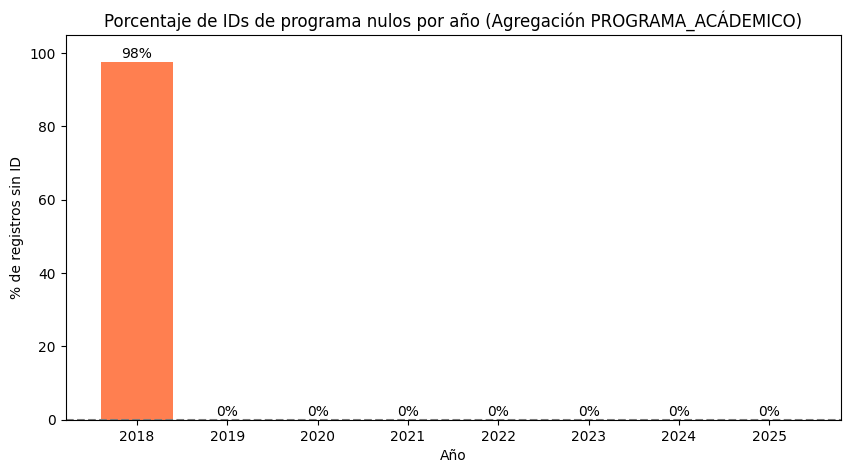

In [22]:
nulos_por_año = sabpro_full[sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO'].groupby('ANIO')['ID_PROGRAMA_ACAD'].apply(lambda x: x.isna().sum())
totales_por_año = sabpro_full[sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO'].groupby('ANIO').size()
porcentaje_nulos = (nulos_por_año / totales_por_año) * 100

plt.figure(figsize=(10,5))
plt.bar(porcentaje_nulos.index, porcentaje_nulos.values, color='coral')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Porcentaje de IDs de programa nulos por año (Agregación PROGRAMA_ACÁDEMICO)')
plt.xlabel('Año')
plt.ylabel('% de registros sin ID')
plt.ylim(0, 105)
for i, (año, pct) in enumerate(porcentaje_nulos.items()):
    plt.text(año, pct + 1, f'{pct:.0f}%', ha='center')
plt.show()

### Conclusiones sobre nulos:
Se encuentra que a nivel de Agregación los nulos se concentran en de Programa Académico. Con una distribución relativamente uniforme entre 12.97%-20.84% en las Medidas de agregación, y en relación con la distribución demográfica 14.57%-23.47% de la cantidad de evaluados.</br>
Sin embargo, en la revisión cronológica se encuentra que en 2018 está el 97.66% de los valores nulos y recordando que durante la importación de la base de datos del año 2018 no se encontraron las columnas: _'ID_REGION', 'ID_DEPARTAMENTO', 'ID_MUNICIPIO', 'ID_GRUPOREFERENCIA', 'ID_NBC', 'ID_PROGRAMA_ACAD', 'CATEGORIAPRUEBA'_, se conclyue que los datos correspondientes a dicho año carecen de una estructura suficiente para adaptar un análisis unificado de los datos.</br>
Por lo tanto se considera prudente no incluir los datos de 2018 en el análisis y se trabajará con los de 2019 en adelante.

### 🚧  Punto de control:
Exportación de dataset final de análisis de datos: _***saberpro_2019_2025_LIMPIO.parquet***_

In [23]:
# =============================================================================
# ELIMINACIÓN DE REGISTROS DEL AÑO 2018 (SIN ID DE PROGRAMA)
# =============================================================================
print("\n=== ELIMINANDO DATOS DEL AÑO 2018 ===")
print(f"Registros totales antes: {len(sabpro_full):,}")
sabpro_full = sabpro_full[sabpro_full['ANIO'] != 2018].copy()
sabpro_full.to_parquet('saberpro_2019_2025_LIMPIO.parquet', index=False)
print(f"Registros después de eliminar 2018: {len(sabpro_full):,}")

# Validación
df_prog = sabpro_full[sabpro_full['AGREGACION'] == 'PROGRAMA_ACÁDEMICO']
nulos = df_prog['ID_PROGRAMA_ACAD'].isna().sum()
if nulos == 0:
    print("✅ Validación exitosa: No hay IDs nulos en PROGRAMA_ACÁDEMICO para 2019-2025.")
else:
    print(f"⚠️ Advertencia: Aún hay {nulos} registros con ID nulo (no debería ocurrir).")


=== ELIMINANDO DATOS DEL AÑO 2018 ===
Registros totales antes: 2,832,345
Registros después de eliminar 2018: 2,301,144
✅ Validación exitosa: No hay IDs nulos en PROGRAMA_ACÁDEMICO para 2019-2025.


## Ajustes finales: reducción de duplicados con normalización de nombres
Se realiza una última normalización con diagnóstico, por dimensiones (para creación de base de datos), para _instituciones_ y _programas_.

In [24]:
# --- Diagnosticar DIM_INSTITUCION ---
df_inst_test = sabpro_full[['ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_SEDE', 'NOMBRE_SEDE']].copy()

# Reemplazar nulos por un valor especial (porque NaN no se compara bien)
df_inst_test['ID_INSTITUCION'] = df_inst_test['ID_INSTITUCION'].fillna(-1).astype(int)
df_inst_test['ID_SEDE'] = df_inst_test['ID_SEDE'].fillna(-1).astype(int)
df_inst_test['NOMBRE_INSTITUCION'] = df_inst_test['NOMBRE_INSTITUCION'].fillna('SIN_DATO')
df_inst_test['NOMBRE_SEDE'] = df_inst_test['NOMBRE_SEDE'].fillna('SIN_DATO')

# Agrupar por (ID_INSTITUCION, ID_SEDE) y contar cuántos nombres diferentes hay
duplicados_inst = df_inst_test.groupby(['ID_INSTITUCION', 'ID_SEDE']).agg(
    num_instituciones_nombres=('NOMBRE_INSTITUCION', 'nunique'),
    num_sedes_nombres=('NOMBRE_SEDE', 'nunique'),
    ejemplo_institucion=('NOMBRE_INSTITUCION', lambda x: x.mode()[0] if not x.empty else None),
    ejemplo_sede=('NOMBRE_SEDE', lambda x: x.mode()[0] if not x.empty else None)
).reset_index()

conflictos = duplicados_inst[(duplicados_inst['num_instituciones_nombres'] > 1) | 
                              (duplicados_inst['num_sedes_nombres'] > 1)]
print(f"Conflictos en DIM_INSTITUCION (mismo ID pero diferentes nombres): {len(conflictos)}")
if len(conflictos) > 0:
    print(conflictos.sample(10))

Conflictos en DIM_INSTITUCION (mismo ID pero diferentes nombres): 16
     ID_INSTITUCION  ID_SEDE  num_instituciones_nombres  num_sedes_nombres  \
119            8964    33843                          1                  2   
294            9072     9072                          2                  1   
22             8897     8897                          1                  2   
293            9072       -1                          2                  1   
52             8914       -1                          2                  1   
408            9160     9160                          2                  2   
424            9175     9175                          1                  2   
489            9243     9243                          2                  2   
319            9088       -1                          2                  1   
488            9243       -1                          2                  1   

                                   ejemplo_institucion  \
119           

In [25]:
# --- Diagnosticar DIM_PROGRAMA ---
df_prog_test = sabpro_full[['ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'NBC']].dropna(subset=['ID_PROGRAMA_ACAD']).copy()
df_prog_test['ID_PROGRAMA_ACAD'] = df_prog_test['ID_PROGRAMA_ACAD'].astype(int)

duplicados_prog = df_prog_test.groupby('ID_PROGRAMA_ACAD').agg(
    num_nombres=('NOMBRE_PROGRAMA_ACAD', 'nunique'),
    num_nbc=('NBC', 'nunique'),
    ejemplo_nombre=('NOMBRE_PROGRAMA_ACAD', 'first')
).reset_index()

conflictos_prog = duplicados_prog[duplicados_prog['num_nombres'] > 1]
print(f"\nConflictos en DIM_PROGRAMA (mismo ID con diferentes nombres): {len(conflictos_prog)}")
if len(conflictos_prog) > 0:
    print(conflictos_prog.head(10))


Conflictos en DIM_PROGRAMA (mismo ID con diferentes nombres): 3
      ID_PROGRAMA_ACAD  num_nombres  num_nbc  \
1085              2211            2        1   
1607              3237            2        1   
3419              7475            2        1   

                                         ejemplo_nombre  
1085        INGENIERÍA DE SISTEMAS Y TELECOMUNICACIONES  
1607  GEOGRAFÍA APLICADA A LA ORGANIZACIÓN DEL ESPAC...  
3419  LICENCIATURA EN EDUCACIÓN BÁSICA CON ÉNFASIS E...  


In [26]:
# =============================================================================
# DETECCIÓN Y EXPORTACIÓN DE CONFLICTOS EN DIMENSIONES
# =============================================================================
print("\n=== DETECTANDO CONFLICTOS PARA CORRECCIÓN MANUAL ===")

# 1. Conflictos en instituciones
df_inst_conflict = sabpro_full[['ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_SEDE', 'NOMBRE_SEDE']].copy()
df_inst_conflict['ID_INSTITUCION'] = df_inst_conflict['ID_INSTITUCION'].fillna(-1).astype(int)
df_inst_conflict['ID_SEDE'] = df_inst_conflict['ID_SEDE'].fillna(-1).astype(int)

# Agrupar y contar variaciones
inst_group = df_inst_conflict.groupby(['ID_INSTITUCION', 'ID_SEDE']).agg(
    num_nombres_inst=('NOMBRE_INSTITUCION', 'nunique'),
    num_nombres_sede=('NOMBRE_SEDE', 'nunique'),
    nombres_inst=('NOMBRE_INSTITUCION', lambda x: list(x.unique())),
    nombres_sede=('NOMBRE_SEDE', lambda x: list(x.unique()))
).reset_index()

conflictos_inst = inst_group[(inst_group['num_nombres_inst'] > 1) | (inst_group['num_nombres_sede'] > 1)]
print(f"Instituciones conflictivas: {len(conflictos_inst)}")

# 2. Conflictos en programas
df_prog_conflict = sabpro_full[['ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD']].dropna(subset=['ID_PROGRAMA_ACAD']).copy()
df_prog_conflict['ID_PROGRAMA_ACAD'] = df_prog_conflict['ID_PROGRAMA_ACAD'].astype(int)

prog_group = df_prog_conflict.groupby('ID_PROGRAMA_ACAD').agg(
    num_nombres=('NOMBRE_PROGRAMA_ACAD', 'nunique'),
    nombres=('NOMBRE_PROGRAMA_ACAD', lambda x: list(x.unique()))
).reset_index()

conflictos_prog = prog_group[prog_group['num_nombres'] > 1]
print(f"Programas conflictivos: {len(conflictos_prog)}")

# Exportar a CSV para edición manual
conflictos_inst.to_csv('conflictos_instituciones.csv', index=False, encoding='utf-8-sig')
conflictos_prog.to_csv('conflictos_programas.csv', index=False, encoding='utf-8-sig')
print("Archivos CSV exportados. Revísalos y crea un diccionario de corrección.")


=== DETECTANDO CONFLICTOS PARA CORRECCIÓN MANUAL ===
Instituciones conflictivas: 16
Programas conflictivos: 3
Archivos CSV exportados. Revísalos y crea un diccionario de corrección.


In [27]:
# =============================================================================
# DETECCIÓN DE CONFLICTOS CON AÑO Y FRECUENCIA
# =============================================================================
print("=== Analizando conflictos con metadatos temporales ===")

# --- Conflictos en instituciones ---
df_inst = sabpro_full[['ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_SEDE', 'NOMBRE_SEDE', 'ANIO']].copy()
df_inst['ID_INSTITUCION'] = df_inst['ID_INSTITUCION'].fillna(-1).astype(int)
df_inst['ID_SEDE'] = df_inst['ID_SEDE'].fillna(-1).astype(int)

# Agrupar para obtener año máximo y contar frecuencias por nombre
def get_max_year_and_freq(group, col_nombre, default='SIN_DATO'):
    # Excluir filas donde el nombre es nulo
    validos = group[group[col_nombre].notna()]
    if validos.empty:
        return default, 0, 0
    
    # Por cada valor de nombre, cuántas apariciones y año máximo
    info = group.groupby(col_nombre)['ANIO'].agg(['max', 'count'])
    info = info.sort_values(['max', 'count'], ascending=[False, False])
    # Sugerencia: el nombre con año más reciente (y mayor frecuencia si empate)
    sugerido = info.index[0]
    return sugerido, info.iloc[0]['max'], info.iloc[0]['count']

conflictos_inst = []
for (id_inst, id_sede), group in df_inst.groupby(['ID_INSTITUCION', 'ID_SEDE']):
    nombres_inst = group['NOMBRE_INSTITUCION'].unique()
    nombres_sede = group['NOMBRE_SEDE'].unique()
    if len(nombres_inst) > 1 or len(nombres_sede) > 1:
        # Obtener sugerencias
        inst_sug, inst_anio, inst_freq = get_max_year_and_freq(group, 'NOMBRE_INSTITUCION')
        sede_sug, sede_anio, sede_freq = get_max_year_and_freq(group, 'NOMBRE_SEDE')
        conflictos_inst.append({
            'ID_INSTITUCION': id_inst,
            'ID_SEDE': id_sede,
            'NUM_NOMBRES_INST': len(nombres_inst),
            'NUM_NOMBRES_SEDE': len(nombres_sede),
            'NOMBRES_INST': ' | '.join([str(n) for n in nombres_inst]),
            'NOMBRES_SEDE': ' | '.join([str(n) for n in nombres_sede]),
            'SUGERENCIA_INST': inst_sug,
            'ANIO_SUGERENCIA_INST': inst_anio,
            'FREC_SUGERENCIA_INST': inst_freq,
            'SUGERENCIA_SEDE': sede_sug,
            'ANIO_SUGERENCIA_SEDE': sede_anio,
            'FREC_SUGERENCIA_SEDE': sede_freq,
        })

df_conflictos_inst = pd.DataFrame(conflictos_inst)
print(f"Instituciones conflictivas: {len(df_conflictos_inst)}")

# Detección de conflictos con programas
df_prog = sabpro_full[['ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'ANIO']].dropna(subset=['ID_PROGRAMA_ACAD']).copy()
df_prog['ID_PROGRAMA_ACAD'] = df_prog['ID_PROGRAMA_ACAD'].astype(int)

conflictos_prog = []
for id_prog, group in df_prog.groupby('ID_PROGRAMA_ACAD'):
    nombres = group['NOMBRE_PROGRAMA_ACAD'].unique()
    if len(nombres) > 1:
        info = group.groupby('NOMBRE_PROGRAMA_ACAD')['ANIO'].agg(['max', 'count'])
        info = info.sort_values(['max', 'count'], ascending=[False, False])
        sugerido = info.index[0]
        conflictos_prog.append({
            'ID_PROGRAMA_ACAD': id_prog,
            'NUM_NOMBRES': len(nombres),
            'NOMBRES': ' | '.join(nombres),
            'SUGERENCIA': sugerido,
            'ANIO_SUGERENCIA': info.iloc[0]['max'],
            'FREC_SUGERENCIA': info.iloc[0]['count']
        })

df_conflictos_prog = pd.DataFrame(conflictos_prog)
print(f"Programas conflictivos: {len(df_conflictos_prog)}")

# Exportación de sugerencias de sugerencias de corrección:
# Exportar
df_conflictos_inst.to_csv('conflictos_instituciones_con_sugerencia.csv', index=False, encoding='utf-8-sig')
df_conflictos_prog.to_csv('conflictos_programas_con_sugerencia.csv', index=False, encoding='utf-8-sig')
print("Archivos exportados. Revise las sugerencias y cree 'mapa_instituciones.csv' y 'mapa_programas.csv'.")

=== Analizando conflictos con metadatos temporales ===
Instituciones conflictivas: 16
Programas conflictivos: 3
Archivos exportados. Revise las sugerencias y cree 'mapa_instituciones.csv' y 'mapa_programas.csv'.


### 🚧  Punto de control: Creación de mapas de correción por dimensiones.
Revisión manual de las sugerencias de corrección y creación de mapas.</br>
**_mapa_instituciones.csv_** y **_mapa_programas.csv_**
### Siguiente paso:
Aplicación de correcciones. Limpieza y deduplicación.

In [28]:
print("\n=== Aplicando correcciones manuales ===")
if os.path.exists('mapa_instituciones.csv'):
    mapa_inst = pd.read_csv('mapa_instituciones.csv', encoding='utf-8-sig')
    for _, row in mapa_inst.iterrows():
        # Filtrar por ID_INSTITUCION y ID_SEDE
        mask = (sabpro_full['ID_INSTITUCION'] == row['ID_INSTITUCION']) & (sabpro_full['ID_SEDE'] == row['ID_SEDE'])
        if not pd.isna(row['NOMBRE_INSTITUCION_CORREGIDO']):
            sabpro_full.loc[mask, 'NOMBRE_INSTITUCION'] = row['NOMBRE_INSTITUCION_CORREGIDO']
        if not pd.isna(row['NOMBRE_SEDE_CORREGIDO']):
            sabpro_full.loc[mask, 'NOMBRE_SEDE'] = row['NOMBRE_SEDE_CORREGIDO']
    print("Correcciones de instituciones aplicadas.")

if os.path.exists('mapa_programas.csv'):
    mapa_prog = pd.read_csv('mapa_programas.csv', encoding='utf-8-sig')
    for _, row in mapa_prog.iterrows():
        mask = sabpro_full['ID_PROGRAMA_ACAD'] == row['ID_PROGRAMA_ACAD']
        sabpro_full.loc[mask, 'NOMBRE_PROGRAMA_ACAD'] = row['NOMBRE_PROGRAMA_CORREGIDO']
    print("Correcciones de programas aplicadas.")


=== Aplicando correcciones manuales ===
Correcciones de instituciones aplicadas.
Correcciones de programas aplicadas.


In [29]:
# =============================================================================
# LIMPIEZA Y DEDUPLICACIÓN DE DIMENSIONES
# =============================================================================
print("\n=== LIMPIEZA DE DIMENSIONES ===")

def normalizar_nombre(texto):
    if pd.isna(texto):
        return 'SIN_DATO'
    texto = str(texto).upper().strip()
    texto = re.sub(r'\s+', ' ', texto)  # múltiples espacios a uno
    # Opcional: eliminar tildes
    # texto = ''.join(c for c in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(c))
    return texto

# -------------------------------------------------------------------------
# 1. DIM_GEOGRAFIA (clave: nombres, sin ID)
# -------------------------------------------------------------------------
geo_raw = sabpro_full[['NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO']].copy()
for col in ['NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO']:
    geo_raw[col] = geo_raw[col].apply(normalizar_nombre)

# Agrupar y tomar primer nombre (todos iguales tras normalización)
geo_dedup = geo_raw.drop_duplicates(subset=['NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO']).reset_index(drop=True)
print(f"  DIM_GEOGRAFIA: {len(geo_dedup)} registros únicos")

# -------------------------------------------------------------------------
# 2. DIM_INSTITUCION (clave: ID_INSTITUCION, ID_SEDE)
# -------------------------------------------------------------------------
inst_raw = sabpro_full[['ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_SEDE', 'NOMBRE_SEDE']].copy()
# Rellenar nulos en IDs con -1 (para agrupar, luego los eliminaremos si no son válidos)
inst_raw['ID_INSTITUCION'] = inst_raw['ID_INSTITUCION'].fillna(-1).astype(int)
inst_raw['ID_SEDE'] = inst_raw['ID_SEDE'].fillna(-1).astype(int)
# Normalizar nombres
inst_raw['NOMBRE_INSTITUCION'] = inst_raw['NOMBRE_INSTITUCION'].apply(normalizar_nombre)
inst_raw['NOMBRE_SEDE'] = inst_raw['NOMBRE_SEDE'].apply(normalizar_nombre)

# Función para elegir nombre canónico (moda, luego el más largo)
def canonical_name(series):
    mode = series.mode()
    if not mode.empty:
        return mode[0]
    # Si hay empate, el más largo (menos abreviado)
    return max(series, key=len)

inst_dedup = inst_raw.groupby(['ID_INSTITUCION', 'ID_SEDE'], as_index=False).agg({
    'NOMBRE_INSTITUCION': canonical_name,
    'NOMBRE_SEDE': canonical_name
})
# Eliminar filas donde ID_INSTITUCION == -1 (sin ID válido) - no pueden ser dimensión
inst_dedup = inst_dedup[inst_dedup['ID_INSTITUCION'] != -1]
print(f"  DIM_INSTITUCION: {len(inst_dedup)} registros únicos")

# -------------------------------------------------------------------------
# 3. DIM_PROGRAMA (clave: ID_PROGRAMA_ACAD)
# -------------------------------------------------------------------------
prog_raw = sabpro_full[['ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'NBC']].dropna(subset=['ID_PROGRAMA_ACAD'])
prog_raw['ID_PROGRAMA_ACAD'] = prog_raw['ID_PROGRAMA_ACAD'].astype(int)
prog_raw['NOMBRE_PROGRAMA_ACAD'] = prog_raw['NOMBRE_PROGRAMA_ACAD'].apply(normalizar_nombre)
prog_raw['NBC'] = prog_raw['NBC'].apply(normalizar_nombre)

prog_dedup = prog_raw.groupby('ID_PROGRAMA_ACAD', as_index=False).agg({
    'NOMBRE_PROGRAMA_ACAD': canonical_name,
    'NBC': canonical_name
})
print(f"  DIM_PROGRAMA: {len(prog_dedup)} registros únicos")

# -------------------------------------------------------------------------
# 4. DIM_PRUEBA (clave: NOMBRE_PRUEBA, aunque AFIRMACION puede variar)
#    Para simplificar, usamos solo NOMBRE_PRUEBA como clave.
# -------------------------------------------------------------------------
pru_raw = sabpro_full[['NOMBRE_PRUEBA', 'AFIRMACION']].copy()
pru_raw['NOMBRE_PRUEBA'] = pru_raw['NOMBRE_PRUEBA'].apply(normalizar_nombre)
pru_raw['AFIRMACION'] = pru_raw['AFIRMACION'].fillna('SIN_AFIRMACION').astype(str)

# Tomar la afirmación más común por prueba (puede haber varias)
pru_dedup = pru_raw.groupby('NOMBRE_PRUEBA', as_index=False).agg({
    'AFIRMACION': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
})
print(f"  DIM_PRUEBA: {len(pru_dedup)} registros únicos")

# -------------------------------------------------------------------------
# 5. DIM_TIEMPO (clave: ANIO)
# -------------------------------------------------------------------------
time_dedup = sabpro_full[['ANIO']].drop_duplicates().sort_values('ANIO').reset_index(drop=True)
time_dedup['id_tiempo'] = time_dedup.index + 1  # surrogate key
print(f"  DIM_TIEMPO: {len(time_dedup)} registros")


=== LIMPIEZA DE DIMENSIONES ===
  DIM_GEOGRAFIA: 102 registros únicos
  DIM_INSTITUCION: 515 registros únicos
  DIM_PROGRAMA: 5323 registros únicos
  DIM_PRUEBA: 49 registros únicos
  DIM_TIEMPO: 7 registros


## **Tercera fase de proceso ETL de analítica:**
### Carga de datos...
Se crea base de datos **SQL** Modelo estrella con 4 dimensiones: _Geografía_, _Institución_, _Programa_ y _Tiempo_, y _Tabla de hechos_

In [30]:
import sqlite3
import time
import pandas as pd

# =============================================================================
# 0. VERIFICACIÓN INICIAL
# =============================================================================
print("="*70)
print("🚀 INICIANDO CONSTRUCCIÓN DEL MODELO ESTRELLA (TODAS LAS AGREGACIONES)")
print("="*70)
print(f"Registros en sabpro_full: {len(sabpro_full):,}")
print(f"Años incluidos: {sorted(sabpro_full['ANIO'].unique())}")
print(f"Agregaciones presentes: {sabpro_full['AGREGACION'].unique().tolist()}")

# =============================================================================
# 1. PREPARAR CONEXIÓN Y ELIMINAR DB ANTERIOR (si existe)
# =============================================================================
db_path = "saberpro_star_schema.db"

# Cerrar conexión previa si existe
try:
    conn.close()
    print("Conexión previa cerrada.")
except NameError:
    pass  # No existía, no hay problema
    
if os.path.exists(db_path):
    os.remove(db_path)
    print("🗑️ Base de datos anterior eliminada.")

conn = sqlite3.connect(db_path)
cur = conn.cursor()
cur.execute("PRAGMA foreign_keys = ON;")
print("✅ Conexión SQLite establecida.")

# =============================================================================
# 2. DEFINICIÓN DEL ESQUEMA (DDL)
# =============================================================================
print("\n📐 Creando estructura de tablas...")

# DIM_GEOGRAFIA (sin ID_DEPARTAMENTO)
cur.execute("""
CREATE TABLE DIM_GEOGRAFIA (
    id_geografia INTEGER PRIMARY KEY AUTOINCREMENT,
    NOMBRE_REGION TEXT,
    NOMBRE_DEPARTAMENTO TEXT,
    NOMBRE_MUNICIPIO TEXT,
    UNIQUE (NOMBRE_REGION, NOMBRE_DEPARTAMENTO, NOMBRE_MUNICIPIO)
);
""")

cur.execute("""
CREATE TABLE DIM_INSTITUCION (
    id_inst_sede INTEGER PRIMARY KEY AUTOINCREMENT,
    ID_INSTITUCION INTEGER,
    NOMBRE_INSTITUCION TEXT,
    ID_SEDE INTEGER,
    NOMBRE_SEDE TEXT,
    UNIQUE (ID_INSTITUCION, ID_SEDE)
);
""")

cur.execute("""
CREATE TABLE DIM_PROGRAMA (
    ID_PROGRAMA_ACAD INTEGER PRIMARY KEY,
    NOMBRE_PROGRAMA_ACAD TEXT,
    NBC TEXT
);
""")

cur.execute("""
CREATE TABLE DIM_PRUEBA (
    id_prueba INTEGER PRIMARY KEY AUTOINCREMENT,
    NOMBRE_PRUEBA TEXT,
    AFIRMACION TEXT
);
""")

cur.execute("""
CREATE TABLE DIM_TIEMPO (
    id_tiempo INTEGER PRIMARY KEY AUTOINCREMENT,
    ANIO INTEGER,
    UNIQUE(ANIO)
);
""")

cur.execute("""
CREATE TABLE FACT_RESULTADOS (
    id_resultado INTEGER PRIMARY KEY AUTOINCREMENT,
    id_geografia INTEGER,
    id_inst_sede INTEGER,
    ID_PROGRAMA_ACAD INTEGER,
    id_prueba INTEGER,
    id_tiempo INTEGER,
    AGREGACION TEXT,
    MEDIDA_AGREGACION TEXT,
    CANTIDADEVALUADOS INTEGER,
    PROMEDIO_PRUEBA REAL,
    PROMEDIO_GLOBAL REAL,
    DESVIACION REAL,
    PROMEDIO_PERCENTIL REAL,
    NIVEL1 REAL, NIVEL2 REAL, NIVEL3 REAL, NIVEL4 REAL, NIVEL5 REAL,
    PORCENTAJERTAINCORRECTA REAL,
    FOREIGN KEY (id_geografia) REFERENCES DIM_GEOGRAFIA(id_geografia),
    FOREIGN KEY (id_inst_sede) REFERENCES DIM_INSTITUCION(id_inst_sede),
    FOREIGN KEY (ID_PROGRAMA_ACAD) REFERENCES DIM_PROGRAMA(ID_PROGRAMA_ACAD),
    FOREIGN KEY (id_prueba) REFERENCES DIM_PRUEBA(id_prueba),
    FOREIGN KEY (id_tiempo) REFERENCES DIM_TIEMPO(id_tiempo)
);
""")
print("✅ Esquema creado correctamente.")

# =============================================================================
# 3. POBLAR DIMENSIONES (usando pandas to_sql, rápido y seguro)
# =============================================================================
print("\n📦 Poblando dimensiones desde DataFrames deduplicados...")

# --- DIM_GEOGRAFIA (sin ID_DEPARTAMENTO) ---
start = time.time()
# geo_dedup no tiene id_departamento, lo creamos como NULL
geo_dedup_sql = geo_dedup.copy()
geo_dedup_sql.columns = ['NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO'] 
# Renombrar para que coincida con la tabla (las columnas ya se llaman igual)
geo_dedup_sql.to_sql("DIM_GEOGRAFIA", conn, if_exists="append", index=False)
print(f"  ✅ DIM_GEOGRAFIA: {len(geo_dedup_sql):,} registros ({time.time()-start:.2f}s)")

# --- DIM_INSTITUCION ---
start = time.time()
# inst_dedup ya tiene las columnas correctas: ID_INSTITUCION, NOMBRE_INSTITUCION, ID_SEDE, NOMBRE_SEDE
inst_dedup.to_sql("DIM_INSTITUCION", conn, if_exists="append", index=False)
print(f"  ✅ DIM_INSTITUCION: {len(inst_dedup):,} registros ({time.time()-start:.2f}s)")

# --- DIM_PROGRAMA ---
start = time.time()
# prog_dedup tiene ID_PROGRAMA_ACAD, NOMBRE_PROGRAMA_ACAD, NBC
prog_dedup.to_sql("DIM_PROGRAMA", conn, if_exists="append", index=False)
print(f"  ✅ DIM_PROGRAMA: {len(prog_dedup):,} registros ({time.time()-start:.2f}s)")

# --- DIM_PRUEBA ---
start = time.time()
pru_dedup.to_sql("DIM_PRUEBA", conn, if_exists="append", index=False)
print(f"  ✅ DIM_PRUEBA: {len(pru_dedup):,} registros ({time.time()-start:.2f}s)")

# --- DIM_TIEMPO ---
start = time.time()
time_dedup.to_sql("DIM_TIEMPO", conn, if_exists="append", index=False)
print(f"  ✅ DIM_TIEMPO: {len(time_dedup):,} registros ({time.time()-start:.2f}s)")

# =============================================================================
# 4. MAPEO DE CLAVES FORÁNEAS USANDO MERGE (rápido, sin apply)
# =============================================================================
print("\n🔗 Mapeando claves foráneas en DataFrame de hechos...")
start_total = time.time()

# Leer dimensiones con sus surrogate keys
geo_keys = pd.read_sql("SELECT id_geografia, NOMBRE_REGION, NOMBRE_DEPARTAMENTO, NOMBRE_MUNICIPIO FROM DIM_GEOGRAFIA", conn)
inst_keys = pd.read_sql("SELECT id_inst_sede, ID_INSTITUCION, NOMBRE_INSTITUCION, ID_SEDE, NOMBRE_SEDE FROM DIM_INSTITUCION", conn)
prog_keys = pd.read_sql("SELECT ID_PROGRAMA_ACAD, NOMBRE_PROGRAMA_ACAD, NBC FROM DIM_PROGRAMA", conn)
pru_keys = pd.read_sql("SELECT id_prueba, NOMBRE_PRUEBA, AFIRMACION FROM DIM_PRUEBA", conn)
time_keys = pd.read_sql("SELECT id_tiempo, ANIO FROM DIM_TIEMPO", conn)

# Hacer los merges (left joins) sobre el DataFrame completo
# Es más rápido hacer una copia y trabajar con columnas específicas
df_hechos = sabpro_full.copy()

# Mapear geografía
start = time.time()
df_hechos = df_hechos.merge(geo_keys, on=['NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO'], how='left')
print(f"  - Geografía mapeada en {time.time()-start:.2f}s")

# Mapear institución/sede
start = time.time()
df_hechos = df_hechos.merge(inst_keys, on=['ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_SEDE', 'NOMBRE_SEDE'], how='left')
print(f"  - Institución/Sede mapeada en {time.time()-start:.2f}s")

# Mapear programa
start = time.time()
df_hechos = df_hechos.merge(prog_keys, on=['ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'NBC'], how='left')
print(f"  - Programa mapeado en {time.time()-start:.2f}s")

# Mapear prueba # Descartada columna 'AFIRMACION'. Genera nombres nulos si la afirmación está ausente.
start = time.time()
df_hechos = df_hechos.merge(pru_keys, on=['NOMBRE_PRUEBA'], how='left')
print(f"  - Prueba mapeada en {time.time()-start:.2f}s")

# Mapear tiempo
start = time.time()
df_hechos = df_hechos.merge(time_keys, on=['ANIO'], how='left')
print(f"  - Tiempo mapeado en {time.time()-start:.2f}s")

# Seleccionar columnas para la tabla de hechos (incluyendo todas las métricas)
df_hechos_final = df_hechos[[
    'id_geografia', 'id_inst_sede', 'ID_PROGRAMA_ACAD', 'id_prueba', 'id_tiempo',
    'AGREGACION', 'MEDIDA_AGREGACION', 'CANTIDADEVALUADOS',
    'PROMEDIO_PRUEBA', 'PROMEDIO_GLOBAL', 'DESVIACION', 'PROMEDIO_PERCENTIL',
    'NIVEL1', 'NIVEL2', 'NIVEL3', 'NIVEL4', 'NIVEL5', 'PORCENTAJERTAINCORRECTA'
]]

print(f"✅ Mapeo completado en {time.time()-start_total:.2f}s")
print(f"   Filas en tabla de hechos: {len(df_hechos_final):,}")

# =============================================================================
# 5. INSERCIÓN EN FACT_RESULTADOS (con chunksize para evitar saturación)
# =============================================================================
print("\n💾 Insertando registros en FACT_RESULTADOS...")
start_insert = time.time()
df_hechos_final.to_sql("FACT_RESULTADOS", conn, if_exists="append", index=False, chunksize=100000)
conn.commit()
print(f"✅ Inserción completada en {time.time()-start_insert:.2f}s")

# =============================================================================
# 6. ESTADÍSTICAS DE NULIDAD (documentación)
# =============================================================================
print("\n📊 RESUMEN DE CLAVES FORÁNEAS NULAS (esperado para agregaciones no específicas)")
nulos_count = df_hechos_final[['id_geografia', 'id_inst_sede', 'ID_PROGRAMA_ACAD', 'id_prueba', 'id_tiempo']].isna().sum()
for col, count in nulos_count.items():
    pct = count / len(df_hechos_final) * 100
    print(f"   {col}: {count:,} nulos ({pct:.2f}%)")

# =============================================================================
# 7. VALIDACIÓN CONSULTA (Top 5 programas con mayor promedio en PUNTAJE_PRUEBA)
# =============================================================================
print("\n🧪 EJECUTANDO VALIDACIÓN (Top 5 programas con mejor promedio)")
query_test = """
SELECT 
    p.nombre_programa_acad AS Programa,
    COUNT(f.id_resultado) AS Total_Registros,
    ROUND(AVG(f.promedio_prueba), 2) AS Promedio_General
FROM FACT_RESULTADOS f
JOIN DIM_PROGRAMA p ON f.id_programa_acad = p.id_programa_acad
WHERE f.agregacion = 'PROGRAMA_ACÁDEMICO' 
  AND f.medida_agregacion = 'PUNTAJE_PRUEBA'
  AND f.promedio_prueba IS NOT NULL
GROUP BY Programa
HAVING Total_Registros >= 1000
ORDER BY Promedio_General DESC
LIMIT 5;
"""
df_valid = pd.read_sql(query_test, conn)
print(df_valid.to_string(index=False))

# =============================================================================
# 8. CIERRE
# =============================================================================
conn.close()
print("\n" + "="*70)
print(f"🎉 BASE DE DATOS CREADA EXITOSAMENTE: {db_path}")
print(f"   Tamaño de la tabla de hechos: {len(df_hechos_final):,} filas")
print("="*70)

🚀 INICIANDO CONSTRUCCIÓN DEL MODELO ESTRELLA (TODAS LAS AGREGACIONES)
Registros en sabpro_full: 2,301,144
Años incluidos: [np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024), np.int16(2025)]
Agregaciones presentes: ['MUNICIPIO', 'DEPARTAMENTO', 'REGIÓN', 'INSTITUCIÓN', 'PAIS', 'SEDE', 'PROGRAMA_ACÁDEMICO', 'NBC_SEDE ', 'NBC', 'NBC_INSTITUCION']
🗑️ Base de datos anterior eliminada.
✅ Conexión SQLite establecida.

📐 Creando estructura de tablas...
✅ Esquema creado correctamente.

📦 Poblando dimensiones desde DataFrames deduplicados...
  ✅ DIM_GEOGRAFIA: 102 registros (0.01s)
  ✅ DIM_INSTITUCION: 515 registros (0.01s)
  ✅ DIM_PROGRAMA: 5,323 registros (0.02s)
  ✅ DIM_PRUEBA: 49 registros (0.01s)
  ✅ DIM_TIEMPO: 7 registros (0.01s)

🔗 Mapeando claves foráneas en DataFrame de hechos...
  - Geografía mapeada en 0.64s
  - Institución/Sede mapeada en 0.63s
  - Programa mapeado en 0.58s
  - Prueba mapeada en 0.44s
  - Tiempo mapeado en 0.64s
✅ Mapeo c

In [31]:
# Consulta de prueba top 10 de promedios para Ingeniería de sistemas y similares (año y departamento)
conn = sqlite3.connect('saberpro_star_schema.db')
query = """
SELECT 
    t.anio,
    g.nombre_departamento,
    p.nombre_programa_acad,
    ROUND(AVG(f.promedio_prueba), 2) AS promedio
FROM FACT_RESULTADOS f
JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
JOIN DIM_GEOGRAFIA g ON f.id_geografia = g.id_geografia
JOIN DIM_PROGRAMA p ON f.id_programa_acad = p.id_programa_acad
WHERE p.nombre_programa_acad LIKE '%INGENIERÍA DE SISTEMAS%'
GROUP BY t.anio, g.nombre_departamento, p.nombre_programa_acad
LIMIT 10;
"""
df_test = pd.read_sql(query, conn)
conn.close()
display(df_test)

,ANIO,NOMBRE_DEPARTAMENTO,NOMBRE_PROGRAMA_ACAD,promedio
0,2019,ANTIOQUIA,INGENIERÍA DE SISTEMAS,145.36
1,2019,ANTIOQUIA,INGENIERÍA DE SISTEMAS E INFORMÁTICA,169.94
2,2019,ANTIOQUIA,INGENIERÍA DE SISTEMAS Y COMPUTACIÓN,177.38
3,2019,ATLANTICO,INGENIERÍA DE SISTEMAS,141.30
4,2019,ATLANTICO,INGENIERÍA DE SISTEMAS DE INFORMACIÓN,140.43
5,2019,ATLANTICO,INGENIERÍA DE SISTEMAS Y COMPUTACIÓN,173.38
6,2019,BOGOTÁ,INGENIERÍA DE SISTEMAS,146.94
7,2019,BOGOTÁ,INGENIERÍA DE SISTEMAS Y COMPUTACIÓN,167.88
8,2019,BOLIVAR,INGENIERÍA DE SISTEMAS,137.02
9,2019,BOYACA,INGENIERÍA DE SISTEMAS,140.04


# Fin de proceso ETL!
## Aspectos relevantes logrados:
**Extracción:** Carga y consolidación de 8 años (2.8M → 2.3M tras limpieza).
**Limpieza:** Corrección de caracteres corruptos (**_¿_**), normalización de textos (tildes, mayúsculas), uso de SNIES para referencia.
**Resolución de conflictos:** Detección manual de 20 registros con ID's seudo-duplicados (16 instituciones + 4 programas) con sugerencias automáticas por año.
**Optimización:** Tipos Int64 para IDs, float32 para métricas, ahorro de memoria (9.5%).
**Modelado estrella:** Tablas DIM_GEOGRAFIA, DIM_INSTITUCION, DIM_PROGRAMA, DIM_PRUEBA, DIM_TIEMPO + FACT_RESULTADOS con claves foráneas nulas permitidas.
**Análisis exploratorio:** Consultas SQL y visualizaciones que ya están generando insights reales.